<a href="https://colab.research.google.com/github/MontanezQuirozRolo/Predicci-n_CVD/blob/main/Predicci%C3%B3n_de_Enfermedades_Cardiovasculares_(CVD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final: Predicción de Enfermedades Cardiovasculares (CVD)

### Grupo 5

---

**Dataset:** CVD Cleaned — Cardiovascular Disease Dataset  
**Variable objetivo:** `Heart_Disease` (Sí / No)  
**Modelos evaluados:** Regresión Logística · Árbol de Decisión · Random Forest · XGBoost  
**Estrategias de balanceo:** Sin resampleo · Undersampling · Oversampling · SMOTE · SMOTE + Undersampling  
**Umbrales de decisión:** 0.35 · 0.40 · 0.50  

---


## 0. Introducción

### Problemática

Las enfermedades cardiovasculares (ECV) representan una de las principales causas de mortalidad
a nivel mundial. La Organización Mundial de la Salud estima que aproximadamente **17.9 millones
de personas** mueren cada año por ECV, lo que equivale al 32 % de todas las muertes globales.

A pesar de que muchos factores de riesgo —como presión arterial, índice de masa corporal (IMC),
hábitos de vida y condiciones crónicas— son medibles y conocidos, en muchos contextos clínicos
no se utilizan de manera integrada ni sistemática para anticipar el riesgo individual de cada
paciente.

### Problema central

> **¿Es posible predecir de manera precisa el riesgo de enfermedad cardiovascular en pacientes
> a partir de sus características clínicas y hábitos de vida, para apoyar la toma de decisiones
> preventivas?**

### Alcance del proyecto

El proyecto analiza datos históricos de pacientes para construir y comparar modelos predictivos
binarios. No contempla implementación clínica real, pero provee una base analítica robusta para
futuras aplicaciones en salud pública y medicina preventiva.

### Justificación

El desarrollo de modelos predictivos en salud permite:
- **Detección temprana** de pacientes en riesgo antes de que se manifiesten síntomas graves.
- **Reducción de costos médicos** al priorizar intervenciones preventivas sobre tratamientos curativos.
- **Mejora en la calidad de vida** al personalizar recomendaciones clínicas.
- **Toma de decisiones basada en evidencia** mediante el uso de técnicas de ciencia de datos.

### Objetivo
Desarrollar un modelo predictivo basado en algoritmos de aprendizaje supervisado capaz de identificar con alta sensibilidad a pacientes con riesgo de enfermedad cardiovascular, permitiendo una intervención clínica preventiva oportuna y la reducción de la tasa de complicaciones graves en la población objetivo.

### Hipótesis

- **H₀ (nula):** No existe una relación significativa entre las variables clínicas/de estilo de
  vida y la predicción del riesgo de ECV.
- **H₁ (alternativa):** Existe una relación significativa entre las variables clínicas/de estilo
  de vida y la predicción del riesgo de ECV, siendo identificable mediante modelos de machine
  learning con métricas superiores a un clasificador aleatorio (AUC > 0.5).


## 1. Funciones de Utilidad

Se definen funciones reutilizables para imputación de valores extremos, imputación de nulos, visualización de la matriz de confusión y la curva ROC. Centralizarlas evita duplicación de código y facilita el mantenimiento.

In [ ]:
# ─── Imputación de valores extremos (outliers) ───────────────────────────────
def imputar_valores_extremos(df, variable, metodo='mediana'):
    """
    Imputa valores extremos (fuera de ±3σ) con la media o la mediana.
    Se prefiere la mediana porque es más robusta ante distribuciones asimétricas.
    """
    if metodo not in ['media', 'mediana']:
        raise ValueError("El método debe ser 'media' o 'mediana'")
    valor = df[variable].mean() if metodo == 'media' else df[variable].median()
    lim_inf = df[variable].mean() - 3 * df[variable].std()
    lim_sup = df[variable].mean() + 3 * df[variable].std()
    df[variable] = df[variable].where(
        (df[variable] >= lim_inf) & (df[variable] <= lim_sup), valor
    )
    return df


# ─── Imputación de valores perdidos ──────────────────────────────────────────
def imputar_valores(df, variable, metodo='mediana', valor_especifico=None):
    """
    Imputa valores perdidos según el método indicado:
    'media', 'mediana', 'moda' o 'valor_especifico'.
    """
    if metodo == 'media':
        imp = df[variable].mean()
    elif metodo == 'mediana':
        imp = df[variable].median()
    elif metodo == 'moda':
        imp = df[variable].mode()[0]
    elif metodo == 'valor_especifico':
        if valor_especifico is None:
            raise ValueError("Proporcione un valor_especifico.")
        imp = valor_especifico
    else:
        raise ValueError("Método no reconocido.")
    df[variable] = df[variable].fillna(imp)
    return df


# ─── Matriz de confusión ──────────────────────────────────────────────────────
def plot_confusion_matrix(cm, title='Matriz de Confusión'):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No (0)', 'Sí (1)'],
                yticklabels=['No (0)', 'Sí (1)'])
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()


# ─── Curva ROC ────────────────────────────────────────────────────────────────
def plot_roc_curve(y_true, y_prob, title='Curva ROC'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='royalblue', lw=2,
             label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='salmon', linestyle='--', lw=1.5,
             label='Clasificador aleatorio')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return roc_auc


# ─── Evaluación completa de un modelo ────────────────────────────────────────
def evaluar_modelo(nombre, y_true, y_pred, y_prob=None,
                   mostrar_graficos=True):
    """
    Imprime el reporte de clasificación, accuracy, F1, AUC y
    muestra la matriz de confusión + curva ROC (opcional).
    Retorna un dict con las métricas para la tabla comparativa.
    """
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    roc_a = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')

    print(f"\n{'='*60}")
    print(f"  MODELO: {nombre}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
                                target_names=['No (0)', 'Sí (1)']))
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    if y_prob is not None:
        print(f"  AUC-ROC  : {roc_a:.4f}")

    if mostrar_graficos:
        cm = confusion_matrix(y_true, y_pred)
        plot_confusion_matrix(cm, title=f'Matriz de Confusión — {nombre}')
        if y_prob is not None:
            plot_roc_curve(y_true, y_prob, title=f'Curva ROC — {nombre}')

    return {
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC-ROC': round(roc_a, 4) if y_prob is not None else float('nan')
    }


## 2. Carga de Librerías

Se importan las librerías necesarias agrupadas por categoría para mejorar la legibilidad. Se suprime el output de advertencias para una salida más limpia.

In [ ]:
# ─── Manipulación de datos ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import skew, kurtosis

# ─── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ─── Balanceo de clases ───────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# ─── Modelos ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ─── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ─── Configuración general ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("✅ Librerías cargadas correctamente.")

from imblearn.pipeline import Pipeline

✅ Librerías cargadas correctamente.


## 3. Carga de Datos

In [ ]:
# Cargar el dataset

df = pd.read_csv('/content/CVD_cleaned.csv')

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(5)


✅ Dataset cargado: 308,854 filas × 19 columnas


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


## 4. Descripción de Variables

A continuación se detalla cada variable del dataset. Conocer el significado de cada variable es
fundamental para tomar decisiones informadas durante el preprocesamiento y la interpretación
de los modelos.

| Variable | Tipo | Descripción |
|---|---|---|
| `General_Health` | Categórica | Autopercepción del estado de salud: Poor / Fair / Good / Very Good / Excellent |
| `Checkup` | Categórica | Tiempo desde el último chequeo médico |
| `Exercise` | Binaria (Sí/No) | Si realizó actividad física en el último mes |
| **`Heart_Disease`** | **Binaria (Sí/No)** | **Variable objetivo: diagnóstico de enfermedad cardiovascular** |
| `Skin_Cancer` | Binaria (Sí/No) | Diagnóstico de cáncer de piel |
| `Other_Cancer` | Binaria (Sí/No) | Diagnóstico de algún otro tipo de cáncer |
| `Depression` | Binaria (Sí/No) | Diagnóstico de depresión |
| `Diabetes` | Binaria (Sí/No) | Diagnóstico de diabetes |
| `Arthritis` | Binaria (Sí/No) | Diagnóstico de artritis |
| `Sex` | Categórica | Sexo biológico: Female / Male |
| `Age_Category` | Ordinal | Rango de edad en grupos de 5 años (18-24 hasta 80+) |
| `Height_(cm)` | Numérica (continua) | Altura en centímetros |
| `Weight_(kg)` | Numérica (continua) | Peso en kilogramos |
| `BMI` | Numérica (continua) | Índice de Masa Corporal |
| `Smoking_History` | Binaria (Sí/No) | Historial de tabaquismo |
| `Alcohol_Consumption` | Numérica (discreta) | Consumo de alcohol en los últimos 30 días |
| `Fruit_Consumption` | Numérica (discreta) | Consumo de frutas en los últimos 30 días |
| `Green_Vegetables_Consumption` | Numérica (discreta) | Consumo de verduras verdes en los últimos 30 días |
| `FriedPotato_Consumption` | Numérica (discreta) | Consumo de papas fritas en los últimos 30 días |


## 5. Exploración Inicial

In [ ]:
# ─── Información general del dataset ─────────────────────────────────────────
print("─── Información general ───────────────────────────────────────────────")
df.info()


─── Información general ───────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       299312 non-null  object 
 2   Exercise                      299312 non-null  object 
 3   Heart_Disease                 299312 non-null  object 
 4   Skin_Cancer                   299312 non-null  object 
 5   Other_Cancer                  299312 non-null  object 
 6   Depression                    299312 non-null  object 
 7   Diabetes                      299312 non-null  object 
 8   Arthritis                     299312 non-null  object 
 9   Sex                           299312 non-null  object 
 10  Age_Category                  299312 non-null  object 
 11  Height_(cm)                   29

In [ ]:
# ─── Estadísticas descriptivas ────────────────────────────────────────────────
print("─── Estadísticas descriptivas (variables numéricas) ───────────────────")
df.describe().round(2)


─── Estadísticas descriptivas (variables numéricas) ───────────────────


,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,299312.00,299312.00,299312.00,299312.00,299312.00,299312.00,299312.00
mean,170.72,83.49,28.55,5.13,29.86,15.11,6.31
std,10.65,21.28,6.48,8.22,24.89,14.92,8.59
min,91.00,24.95,12.02,0.00,0.00,0.00,0.00
25%,163.00,68.04,24.21,0.00,12.00,4.00,2.00
50%,170.00,81.65,27.44,1.00,30.00,12.00,4.00
75%,178.00,95.25,31.71,6.00,30.00,20.00,8.00
max,241.00,293.02,99.33,30.00,120.00,128.00,128.00


In [ ]:
# ─── Valores duplicados ───────────────────────────────────────────────────────
dup = df.duplicated().sum()
print(f"Filas duplicadas: {dup:,}")
print("→ No se eliminan duplicados en este punto ya que pueden ser respuestas")
print("  legítimamente iguales de distintas personas en una encuesta masiva.")


Filas duplicadas: 80
→ No se eliminan duplicados en este punto ya que pueden ser respuestas
  legítimamente iguales de distintas personas en una encuesta masiva.


In [ ]:
# ─── Valores perdidos ─────────────────────────────────────────────────────────
nulos = df.isnull().sum()
print("Valores perdidos por columna:")
print(nulos[nulos > 0].to_string())
print()
print(f"Total filas con al menos un nulo: {df.isnull().any(axis=1).sum():,}")
print(f"Porcentaje sobre total: {df.isnull().any(axis=1).mean()*100:.2f}%")
print()
print("Nota: Se observa que exactamente las mismas 9,542 filas tienen nulos")
print("en TODAS las columnas (excepto General_Health, que absorbe el contenido")
print("completo de la fila por un problema de parseo del CSV). Estas filas se")
print("eliminarán en la limpieza de datos.")


Valores perdidos por columna:
Checkup                         9542
Exercise                        9542
Heart_Disease                   9542
Skin_Cancer                     9542
Other_Cancer                    9542
Depression                      9542
Diabetes                        9542
Arthritis                       9542
Sex                             9542
Age_Category                    9542
Height_(cm)                     9542
Weight_(kg)                     9542
BMI                             9542
Smoking_History                 9542
Alcohol_Consumption             9542
Fruit_Consumption               9542
Green_Vegetables_Consumption    9542
FriedPotato_Consumption         9542

Total filas con al menos un nulo: 9,542
Porcentaje sobre total: 3.09%

Nota: Se observa que exactamente las mismas 9,542 filas tienen nulos
en TODAS las columnas (excepto General_Health, que absorbe el contenido
completo de la fila por un problema de parseo del CSV). Estas filas se
eliminarán en la lim

## 6. Limpieza de Datos

### Diagnóstico

Al revisar los valores perdidos se detectó que **9,542 filas presentan nulos en todas las
columnas** (excepto `General_Health`). Esto ocurre porque esas filas tienen todos sus valores
concatenados en la primera columna debido a un error de parseo del archivo CSV original.

**Decisión:** Eliminar estas filas, ya que no es posible recuperar la información correctamente
sin el archivo fuente original y representan apenas el **3.09 %** del total de registros.


In [ ]:
# ─── Eliminar filas corruptas (sin Heart_Disease) ────────────────────────────
filas_antes = len(df)
df = df.dropna(subset=['Heart_Disease'])
filas_despues = len(df)
print(f"Filas eliminadas: {filas_antes - filas_despues:,}  →  Dataset limpio: {filas_despues:,} filas")


Filas eliminadas: 9,542  →  Dataset limpio: 299,312 filas


In [ ]:
# ─── Verificar que no queden nulos en el dataset limpio ───────────────────────
print("Valores nulos tras limpieza:")
print(df.isnull().sum().to_string())
print()
print(f"✅ Dataset sin valores perdidos: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Valores nulos tras limpieza:
General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0

✅ Dataset sin valores perdidos: 299,312 filas × 19 columnas


In [ ]:
# ─── Definir grupos de variables por tipo ─────────────────────────────────────
# Variables numéricas continuas / de conteo
cols_numericas = [
    'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

# Variables categóricas binarias (Yes/No)
cols_binarias = [
    'Exercise', 'Skin_Cancer', 'Other_Cancer',
    'Depression', 'Diabetes', 'Arthritis', 'Smoking_History'
]

# Variables categóricas no binarias
cols_categoricas = ['General_Health', 'Checkup', 'Sex', 'Age_Category']

# Variable objetivo
target = 'Heart_Disease'

print("Variables numéricas:", cols_numericas)
print("Variables binarias:", cols_binarias)
print("Variables categóricas:", cols_categoricas)
print("Variable objetivo:", target)


Variables numéricas: ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
Variables binarias: ['Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Smoking_History']
Variables categóricas: ['General_Health', 'Checkup', 'Sex', 'Age_Category']
Variable objetivo: Heart_Disease


In [ ]:
# ─── Tratamiento de outliers en variables numéricas ──────────────────────────
# Se usa la regla de ±3σ: valores fuera de ese rango se imputan con la mediana,
# ya que la mediana es más robusta ante distribuciones asimétricas.

print("Outliers detectados y tratados (regla ±3σ):")
for col in cols_numericas:
    lim_inf = df[col].mean() - 3 * df[col].std()
    lim_sup = df[col].mean() + 3 * df[col].std()
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    if n_out > 0:
        df = imputar_valores_extremos(df, col, metodo='mediana')
        print(f"  ✔ {col:<32} {n_out:>6,} outliers imputados con mediana")
    else:
        print(f"  – {col:<32} sin outliers")

print(f"\n✅ Dataset final limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Outliers detectados y tratados (regla ±3σ):
  ✔ Height_(cm)                         652 outliers imputados con mediana
  ✔ Weight_(kg)                       3,080 outliers imputados con mediana
  ✔ BMI                               3,848 outliers imputados con mediana
  ✔ Alcohol_Consumption              11,685 outliers imputados con mediana
  ✔ Fruit_Consumption                 3,021 outliers imputados con mediana
  ✔ Green_Vegetables_Consumption     11,309 outliers imputados con mediana
  ✔ FriedPotato_Consumption           2,105 outliers imputados con mediana

✅ Dataset final limpio: 299,312 filas × 19 columnas


## 7. Análisis Exploratorio de Datos (EDA)

### 7.1 Variable Objetivo: Heart_Disease

Analizamos la distribución de la variable a predecir. Es fundamental conocer el nivel de
desbalance para elegir las estrategias de balanceo adecuadas.


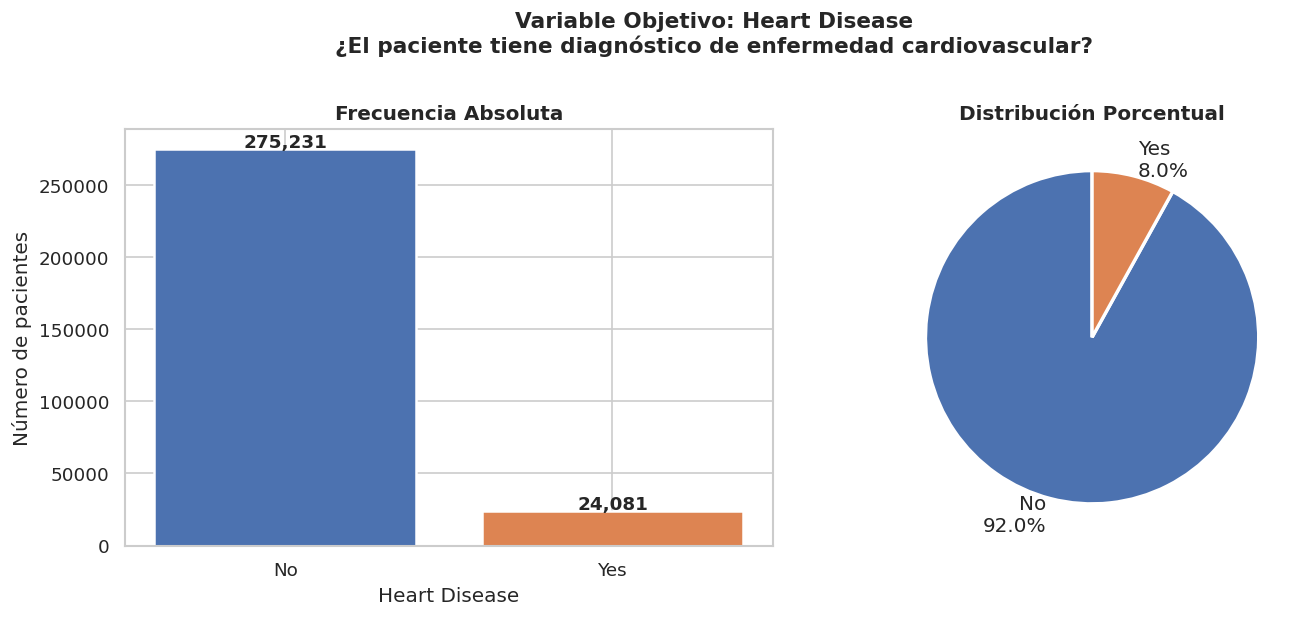

No (sin ECV): 275,231  (91.95%)
Sí (con ECV): 24,081  (8.05%)

Relación de desbalance: 11.4:1
→ El dataset está DESBALANCEADO: hay ~11.4 veces más casos 'No' que 'Sí'.
→ Se aplicarán técnicas de resampling para balancear las clases.


In [ ]:
# ─── Distribución de la variable objetivo ────────────────────────────────────
conteo = df[target].value_counts()
porcs  = df[target].value_counts(normalize=True).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(conteo.index, conteo.values, color=colors,
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Frecuencia Absoluta', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de pacientes')
axes[0].set_xlabel('Heart Disease')
for bar, val in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# Pie
axes[1].pie(
    conteo.values,
    labels=[f'{lbl}\n{pct:.1f}%' for lbl, pct in zip(conteo.index, porcs)],
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
axes[1].set_title('Distribución Porcentual', fontsize=12, fontweight='bold')

plt.suptitle('Variable Objetivo: Heart Disease\n'
             '¿El paciente tiene diagnóstico de enfermedad cardiovascular?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"No (sin ECV): {conteo['No']:,}  ({porcs['No']:.2f}%)")
print(f"Sí (con ECV): {conteo['Yes']:,}  ({porcs['Yes']:.2f}%)")
print(f"\nRelación de desbalance: {conteo['No']/conteo['Yes']:.1f}:1")
print("→ El dataset está DESBALANCEADO: hay ~11.4 veces más casos 'No' que 'Sí'.")
print("→ Se aplicarán técnicas de resampling para balancear las clases.")


### 7.2 Variables Numéricas

Análisis descriptivo de las variables numéricas del dataset, incluyendo distribución e identificación de asimetrías.

In [ ]:
# ─── Estadísticas descriptivas ────────────────────────────────────────────────
desc = df[cols_numericas].describe().round(2)
print(desc.to_string())

print("\n── Asimetría y Curtosis ──────────────────────────────────────────────────")
for col in cols_numericas:
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    interpretacion = "alta asimetría" if abs(s) > 1 else ("moderada" if abs(s) > 0.5 else "simétrica")
    print(f"  {col:<36} Asimetría: {s:+.2f}  Curtosis: {k:+.2f}  → {interpretacion}")


       Height_(cm)  Weight_(kg)        BMI  Alcohol_Consumption  Fruit_Consumption  Green_Vegetables_Consumption  FriedPotato_Consumption
count    299312.00    299312.00  299312.00            299312.00          299312.00                     299312.00                299312.00
mean        170.73        82.62      28.21                 4.00              28.95                         12.95                     5.84
std          10.47        19.45       5.74                 6.55              23.16                          9.86                     6.38
min         140.00        24.95      12.02                 0.00               0.00                          0.00                     0.00
25%         163.00        68.04      24.21                 0.00              12.00                          4.00                     2.00
50%         170.00        81.65      27.44                 1.00              30.00                         12.00                     4.00
75%         178.00        94.35   

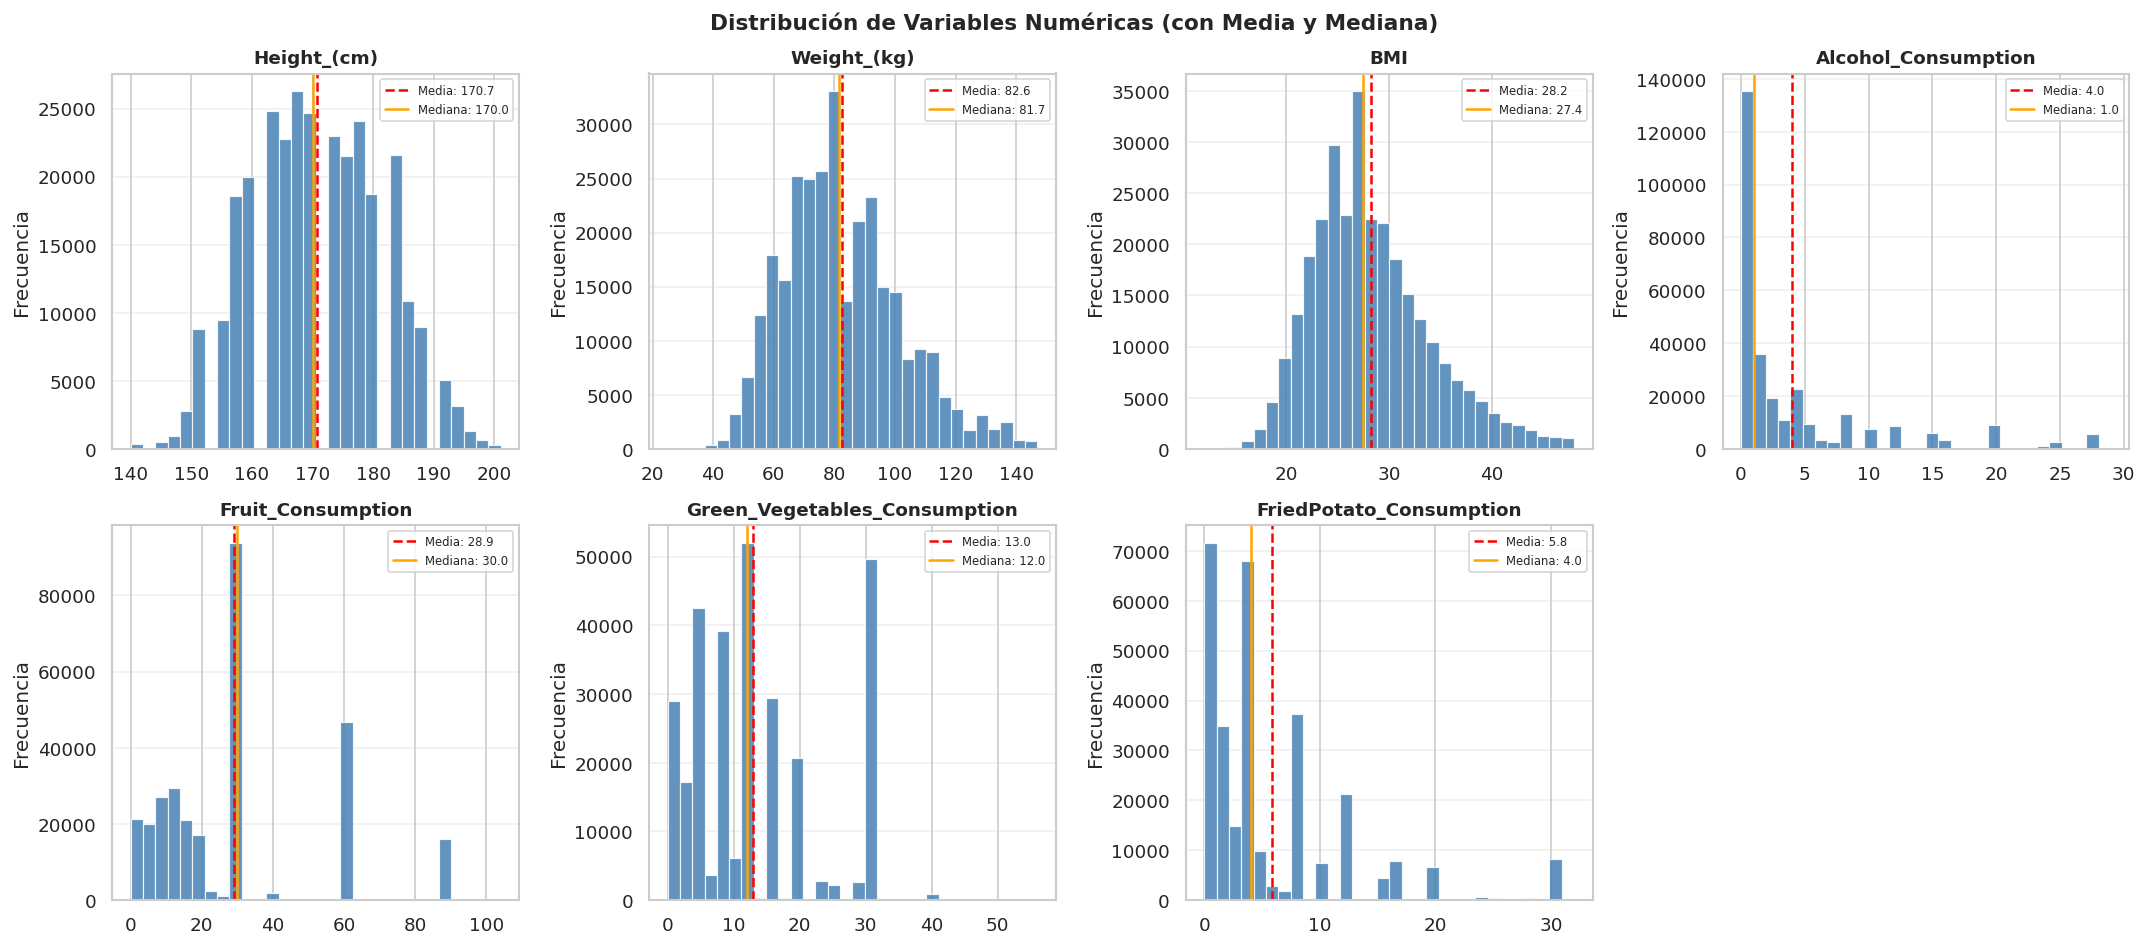

In [ ]:
# ─── Histogramas de variables numéricas ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    axes[i].hist(df[col], bins=30, color='steelblue',
                 edgecolor='white', linewidth=0.7, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.3)
    # Líneas de media y mediana
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', lw=1.5,
                    label=f'Media: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', lw=1.5,
                    label=f'Mediana: {df[col].median():.1f}')
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribución de Variables Numéricas (con Media y Mediana)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


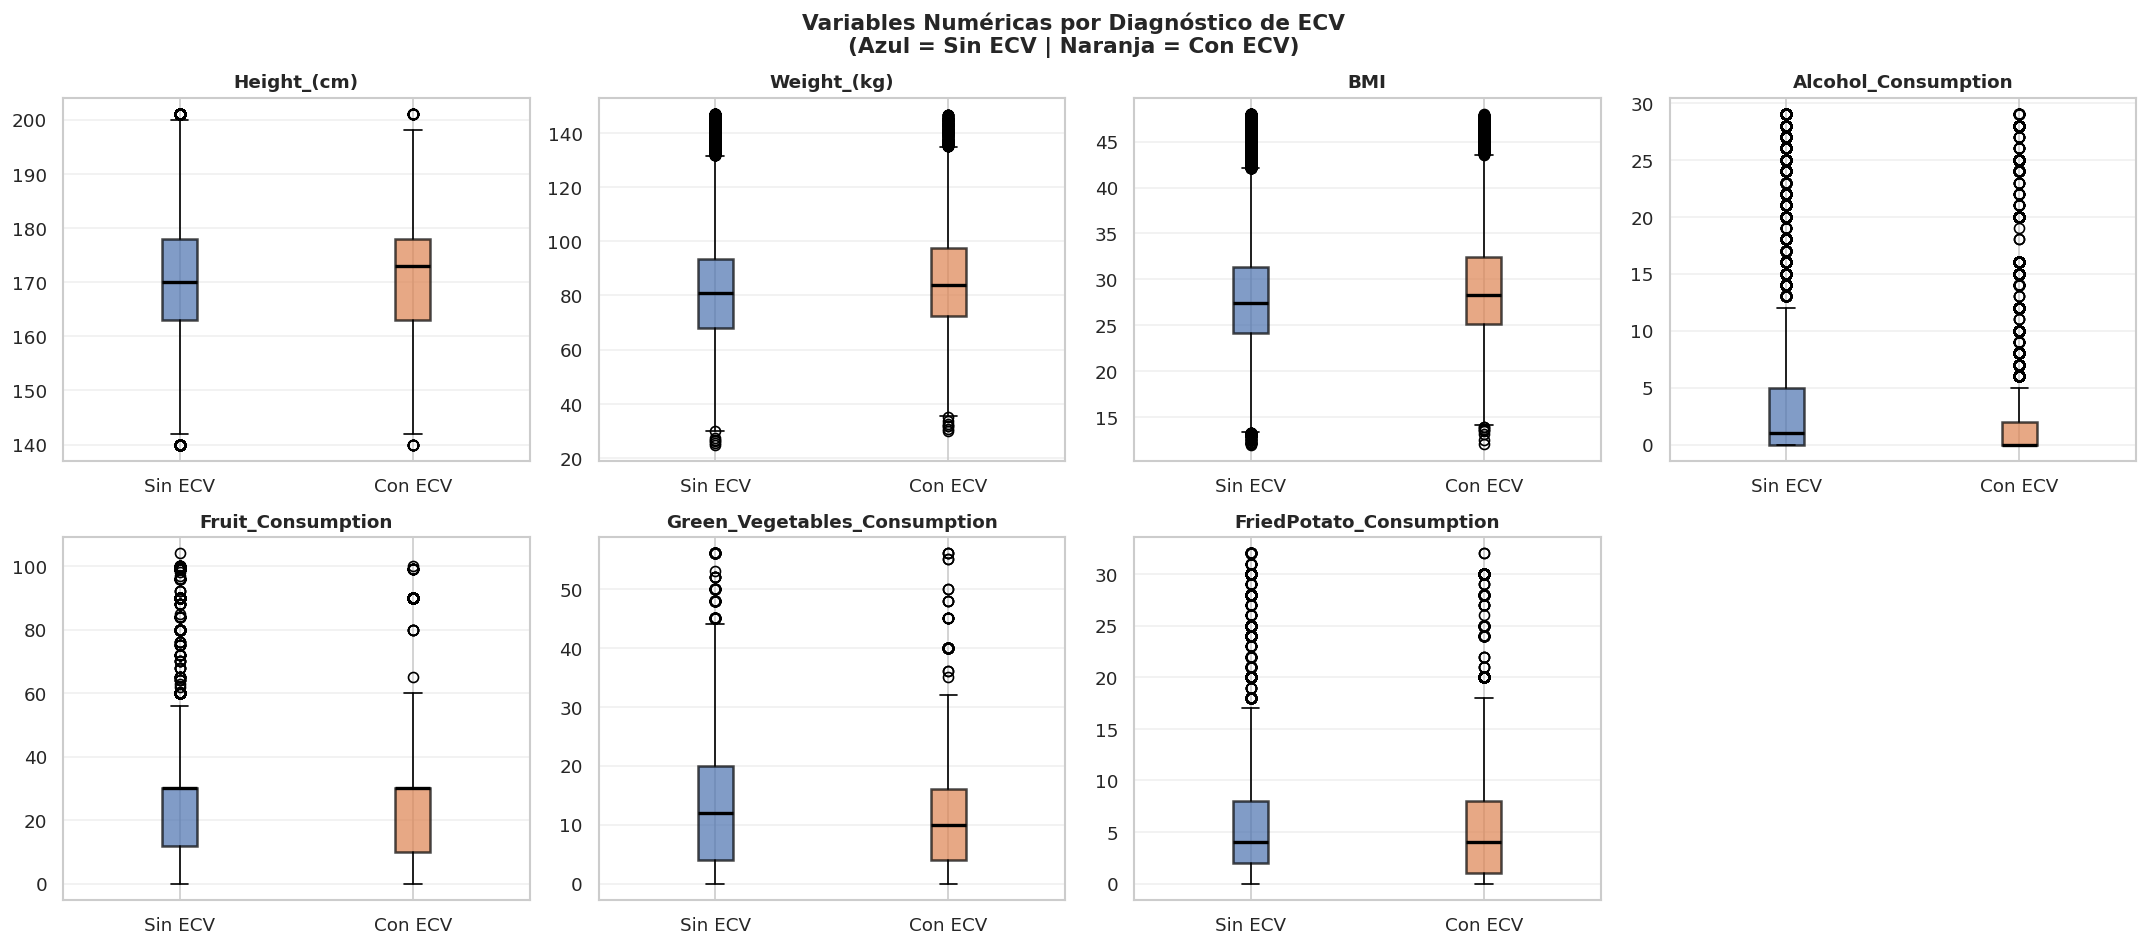

In [ ]:
# ─── Boxplots por Heart_Disease ──────────────────────────────────────────────
# Visualiza si existe diferencia en la distribución de cada variable numérica
# entre pacientes con y sin enfermedad cardiovascular.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    data_no  = df[df[target] == 'No'][col]
    data_yes = df[df[target] == 'Yes'][col]
    bp = axes[i].boxplot(
        [data_no, data_yes],
        labels=['Sin ECV', 'Con ECV'],
        patch_artist=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#DD8452')
    bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Variables Numéricas por Diagnóstico de ECV\n'
             '(Azul = Sin ECV | Naranja = Con ECV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 Variables Categóricas

Análisis de las variables categóricas y su relación con la variable objetivo `Heart_Disease`.

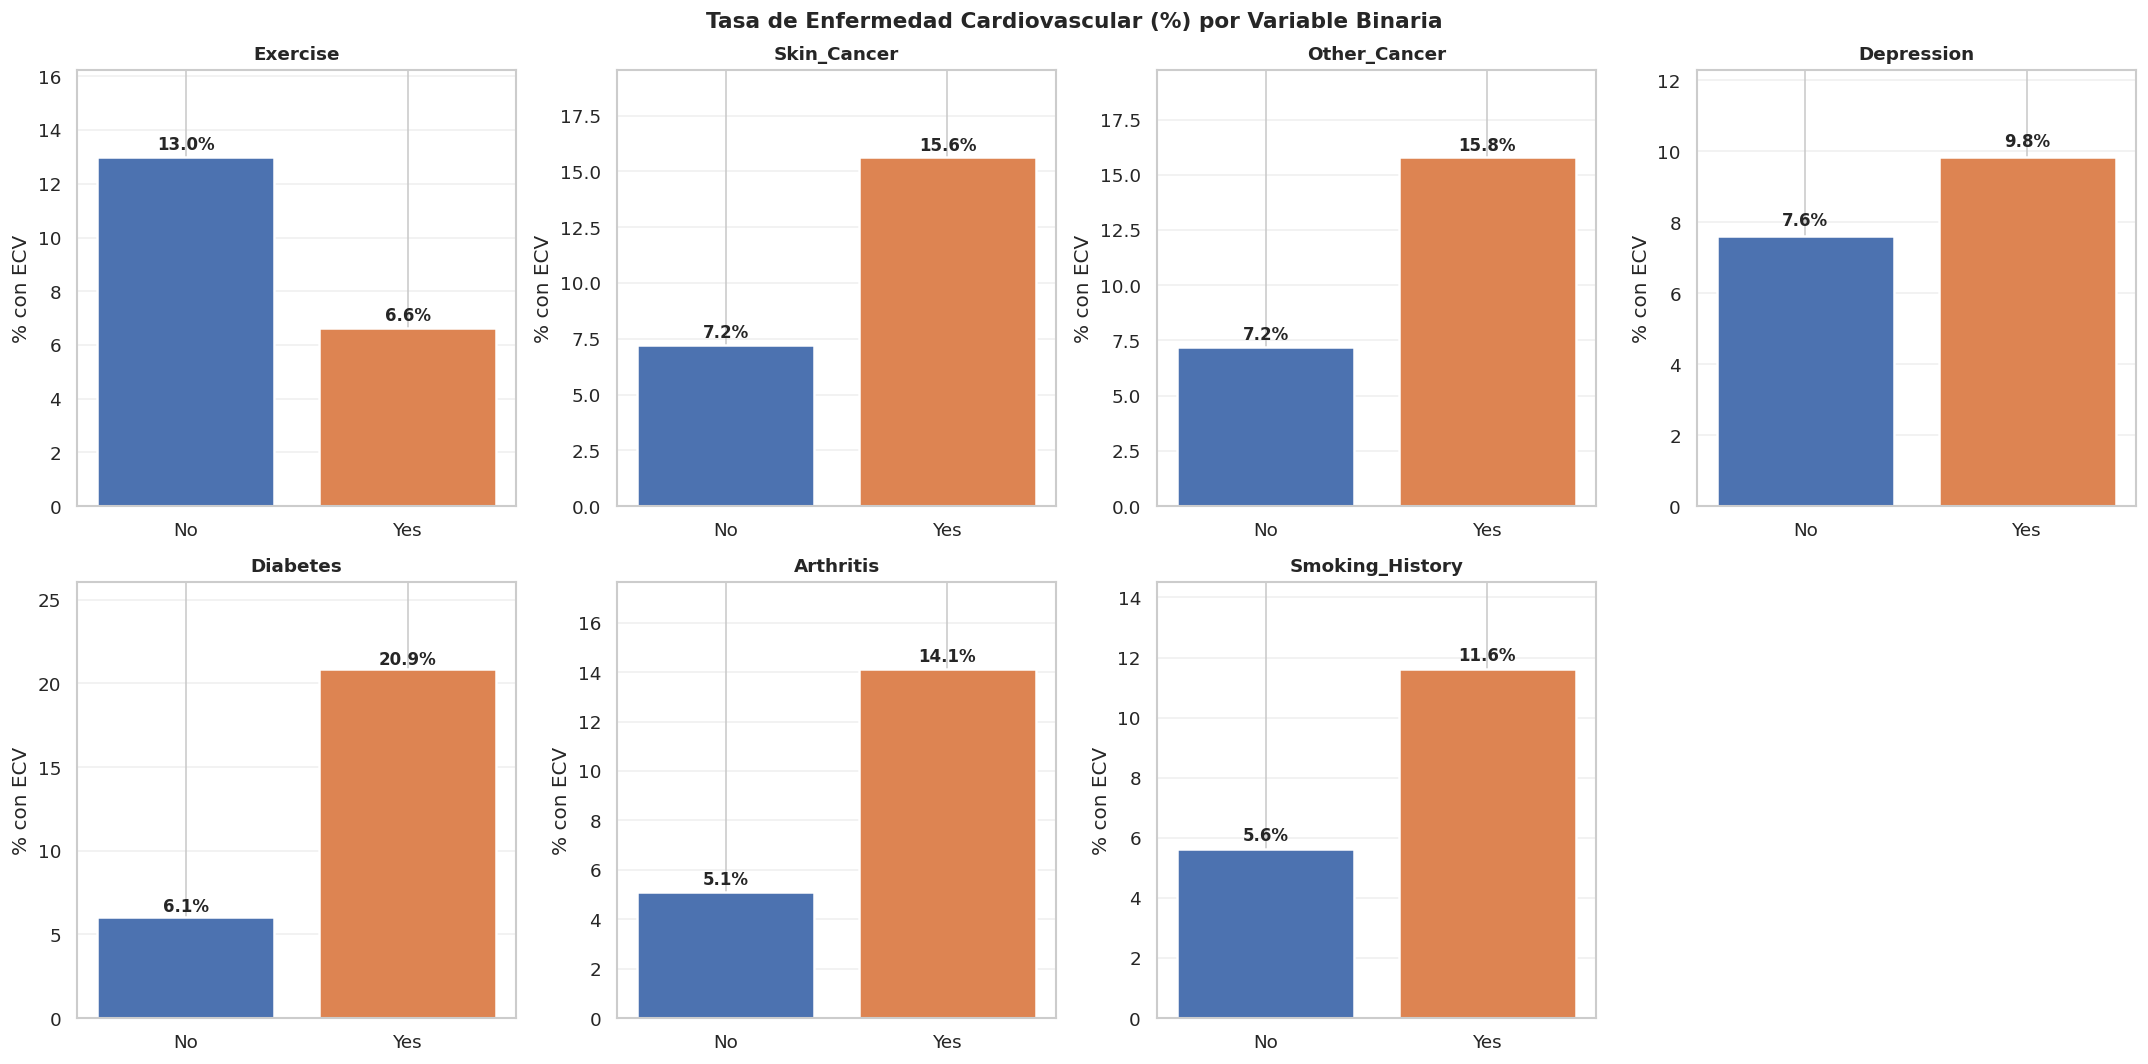

In [ ]:
# ─── Tasa de ECV por variable binaria ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cols_binarias):
    tasa = df.groupby(col)[target].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    tasa.columns = [col, 'Tasa_ECV']

    colors_bar = ['#4C72B0', '#DD8452']
    bars = axes[i].bar(tasa[col], tasa['Tasa_ECV'],
                       color=colors_bar[:len(tasa)],
                       edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, tasa['Tasa_ECV']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% con ECV')
    axes[i].set_ylim(0, tasa['Tasa_ECV'].max() * 1.25)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Tasa de Enfermedad Cardiovascular (%) por Variable Binaria',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


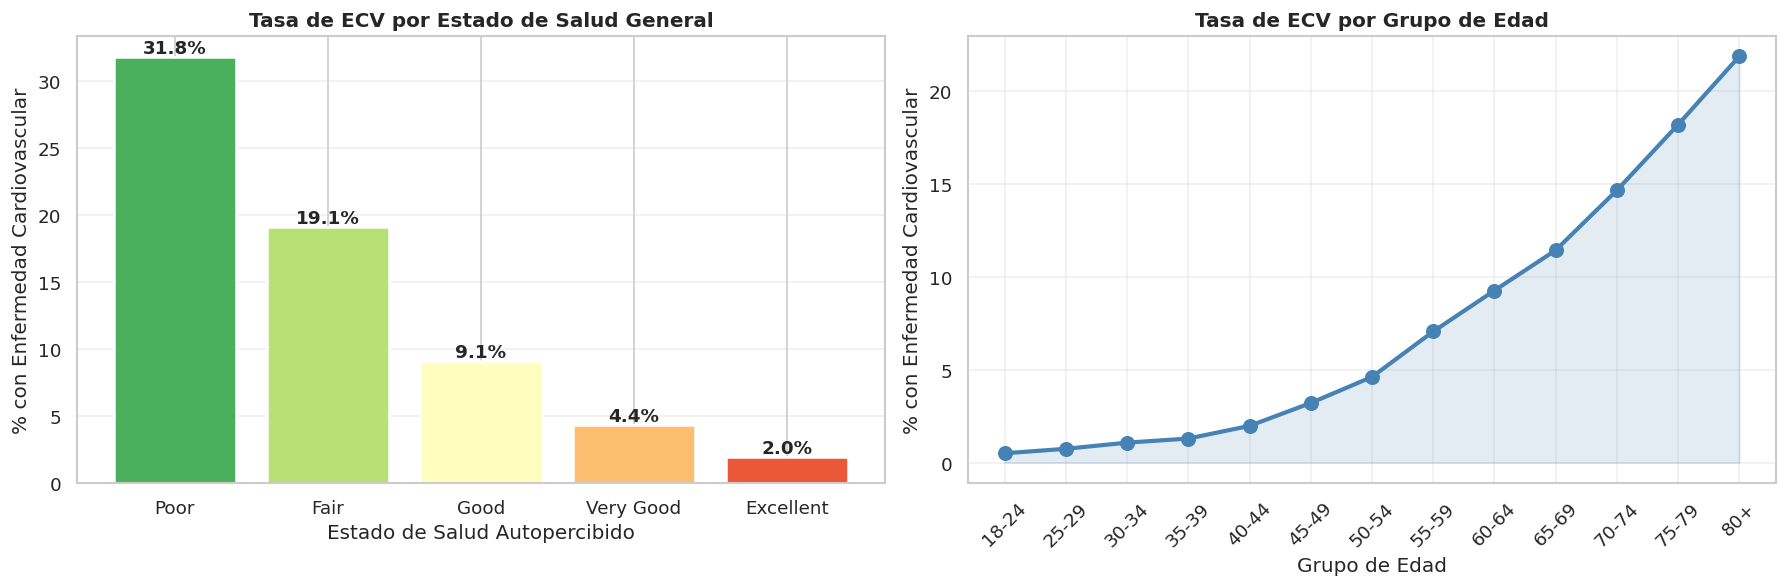

Observación: La tasa de ECV aumenta claramente con la edad y es más alta
en personas con peor autopercepción de salud.


In [ ]:
# ─── General_Health y Heart Disease ──────────────────────────────────────────
orden_salud = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
tasa_gh = df.groupby('General_Health')[target].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(orden_salud).reset_index()
tasa_gh.columns = ['General_Health', 'Tasa_ECV']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tasa de ECV
palette = sns.color_palette("RdYlGn_r", n_colors=5)
bars = axes[0].bar(tasa_gh['General_Health'], tasa_gh['Tasa_ECV'],
                   color=palette, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tasa_gh['Tasa_ECV']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Tasa de ECV por Estado de Salud General',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('% con Enfermedad Cardiovascular')
axes[0].set_xlabel('Estado de Salud Autopercibido')
axes[0].grid(axis='y', alpha=0.3)

# Age_Category
orden_edad = ['18-24','25-29','30-34','35-39','40-44','45-49',
              '50-54','55-59','60-64','65-69','70-74','75-79','80+']
tasa_edad = df.groupby('Age_Category')[target].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(orden_edad).reset_index()
tasa_edad.columns = ['Age_Category', 'Tasa_ECV']

axes[1].plot(tasa_edad['Age_Category'], tasa_edad['Tasa_ECV'],
             marker='o', color='steelblue', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(tasa_edad)), tasa_edad['Tasa_ECV'],
                     alpha=0.15, color='steelblue')
axes[1].set_xticks(range(len(tasa_edad)))
axes[1].set_xticklabels(tasa_edad['Age_Category'], rotation=45)
axes[1].set_title('Tasa de ECV por Grupo de Edad',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('% con Enfermedad Cardiovascular')
axes[1].set_xlabel('Grupo de Edad')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Observación: La tasa de ECV aumenta claramente con la edad y es más alta")
print("en personas con peor autopercepción de salud.")


### 7.4 Indicadores Cardiovasculares por Género

Un análisis diferenciado por sexo es esencial en salud cardiovascular, ya que la literatura
médica documenta diferencias biológicas y de comportamiento entre hombres y mujeres en cuanto
a factores de riesgo. Se analizan las principales variables segmentadas por `Sex` para
identificar patrones diferenciales.


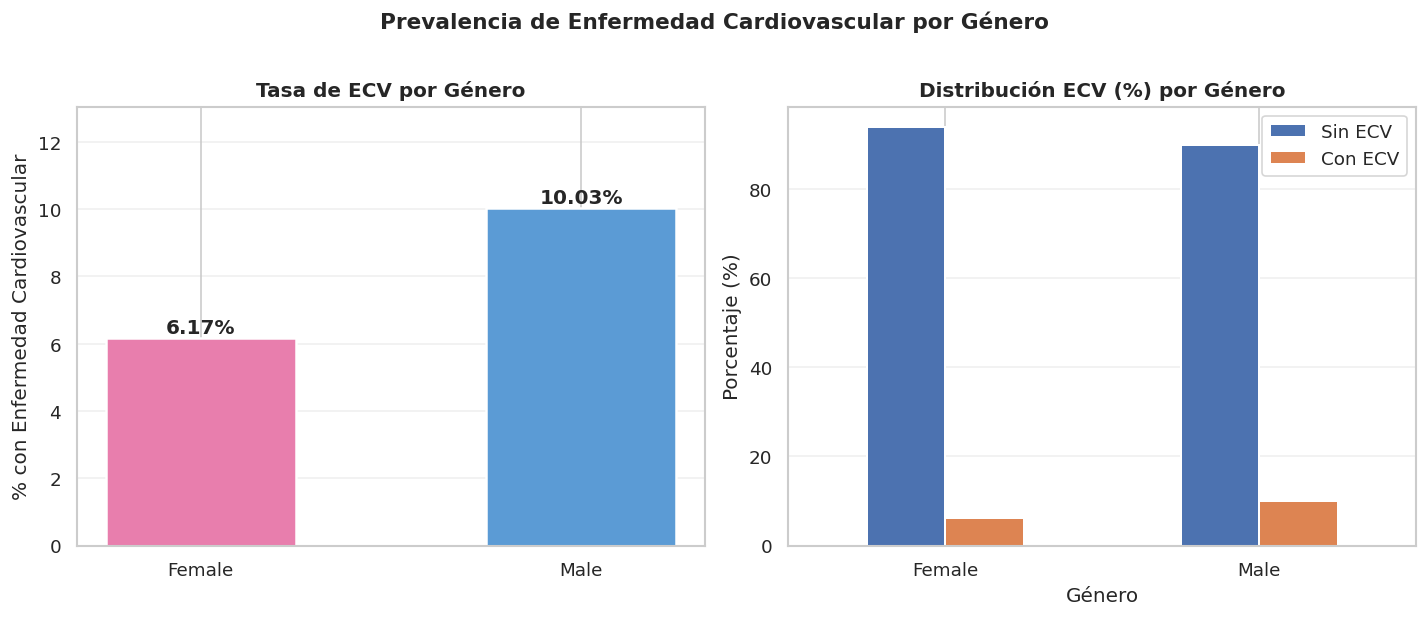

In [ ]:
# ─── Prevalencia de ECV por género ───────────────────────────────────────────
tasa_sexo = df.groupby('Sex')[target].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
tasa_sexo.columns = ['Sex', 'Tasa_ECV']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colores_sexo = {'Female': '#E87EAD', 'Male': '#5B9BD5'}

bars = axes[0].bar(
    tasa_sexo['Sex'], tasa_sexo['Tasa_ECV'],
    color=[colores_sexo.get(s, 'gray') for s in tasa_sexo['Sex']],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, tasa_sexo['Tasa_ECV']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Tasa de ECV por Género', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% con Enfermedad Cardiovascular')
axes[0].set_ylim(0, tasa_sexo['Tasa_ECV'].max() * 1.3)
axes[0].grid(axis='y', alpha=0.3)

# Conteo absoluto con stacked bar
pivot = df.groupby(['Sex', target]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'],
               edgecolor='white', linewidth=1.2)
axes[1].set_title('Distribución ECV (%) por Género', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('Género')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Sin ECV', 'Con ECV'])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Prevalencia de Enfermedad Cardiovascular por Género',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


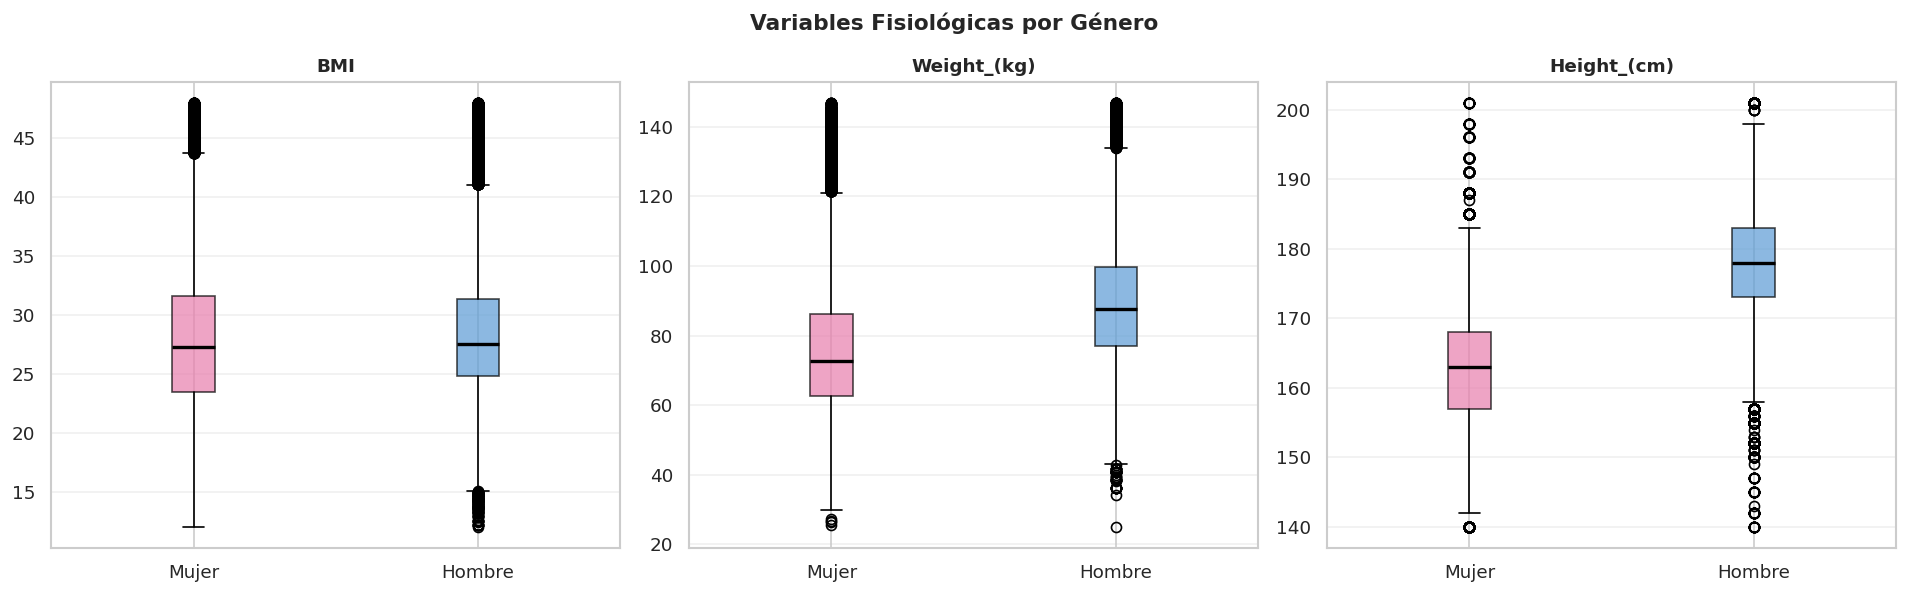

In [ ]:
# ─── Indicadores numéricos (BMI, Peso, Talla) por género ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_fisiologicas = ['BMI', 'Weight_(kg)', 'Height_(cm)']
for i, col in enumerate(vars_fisiologicas):
    datos = [df[df['Sex'] == 'Female'][col], df[df['Sex'] == 'Male'][col]]
    bp = axes[i].boxplot(datos, labels=['Mujer', 'Hombre'],
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#E87EAD')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#5B9BD5')
    bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Variables Fisiológicas por Género',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


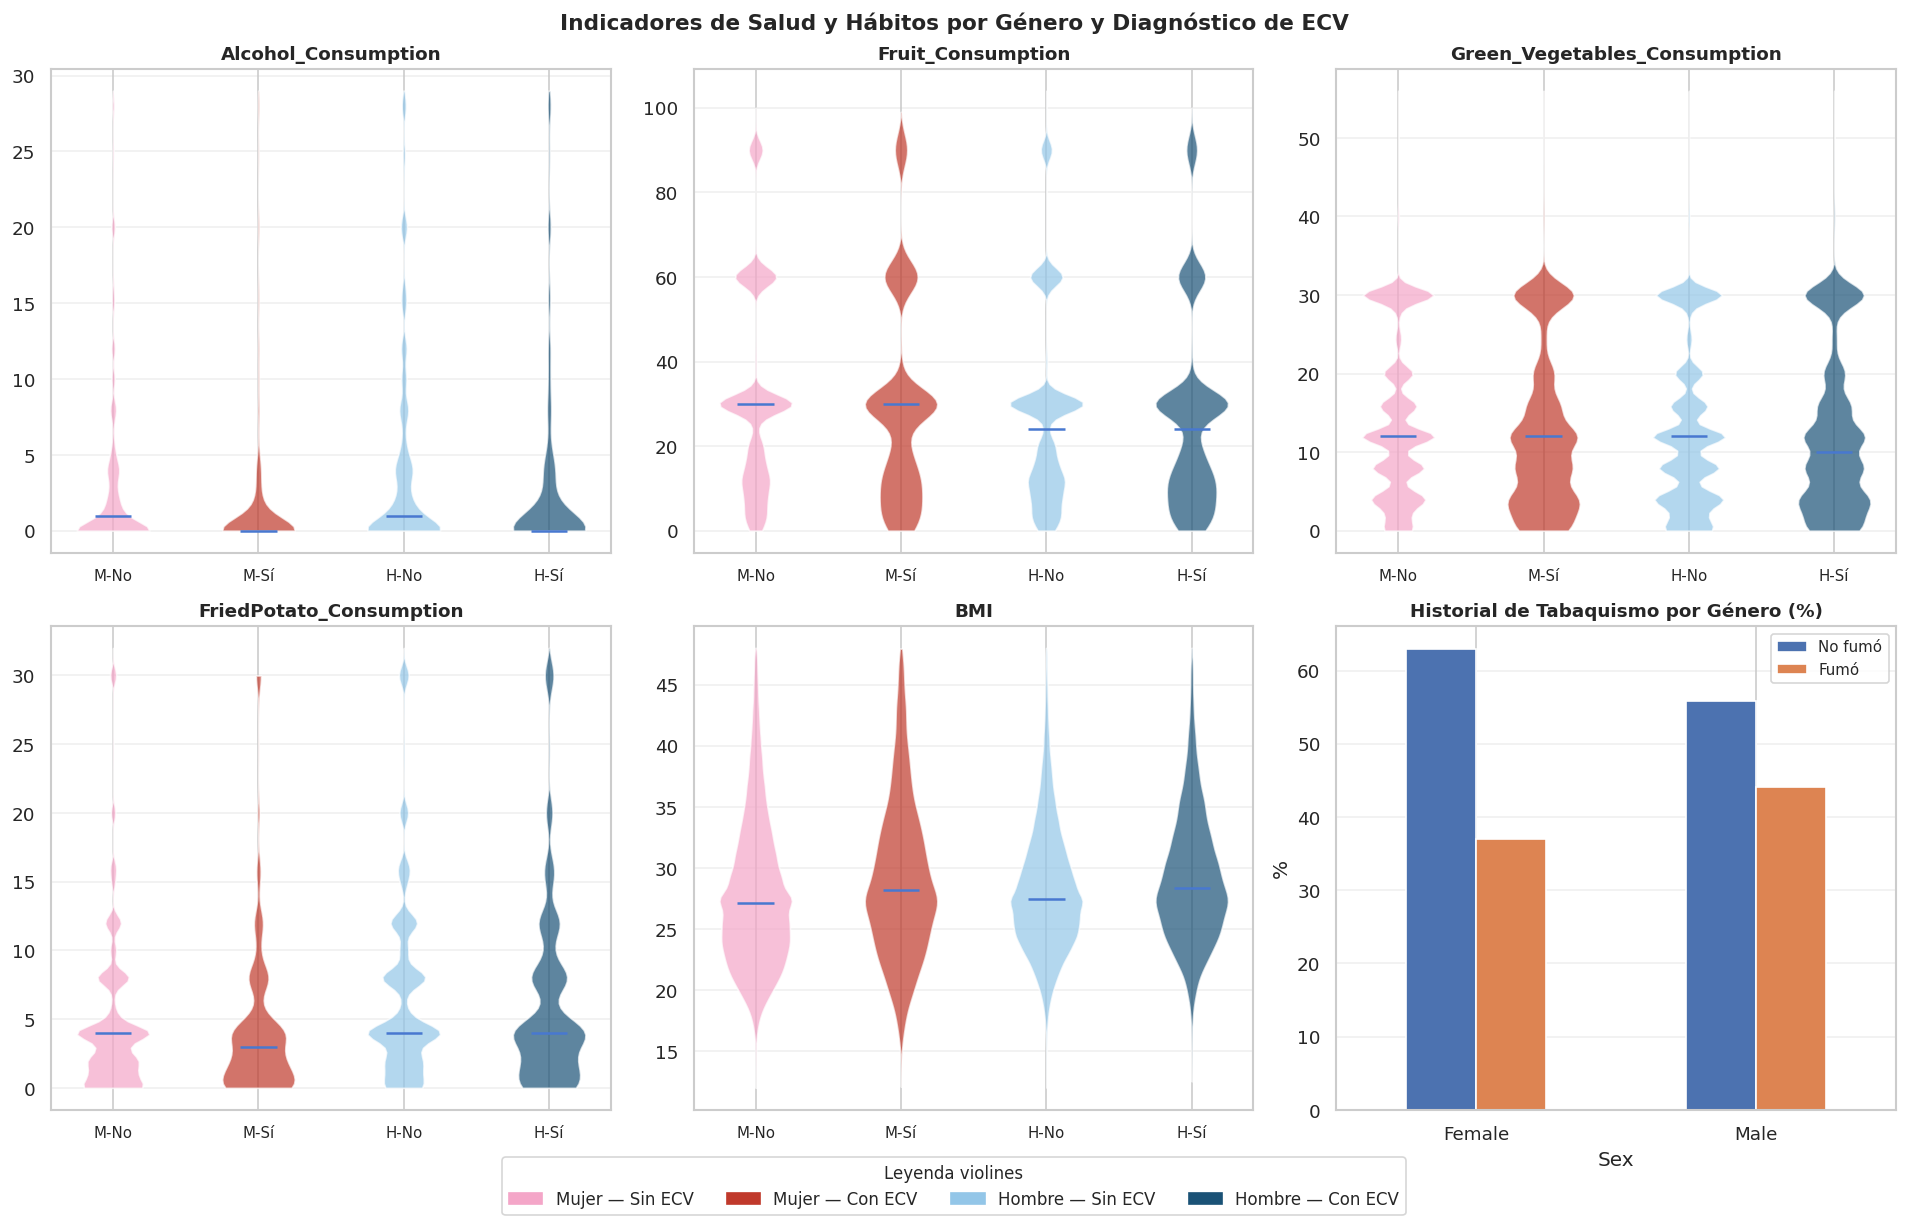

In [ ]:
# ─── Consumos de alimentos / alcohol por género y ECV ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

vars_habitos = [
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption',
    'BMI'
]

for idx, col in enumerate(vars_habitos):
    ax = axes[idx // 3][idx % 3]
    # Violín por género, separando ECV
    data_plot = df[[col, 'Sex', target]].copy()
    data_plot['Grupo'] = data_plot['Sex'] + ' — ' + data_plot[target]
    grupos = ['Female — No', 'Female — Yes', 'Male — No', 'Male — Yes']
    datos = [data_plot[data_plot['Grupo'] == g][col].values for g in grupos]
    colores_v = ['#F4A6C8', '#C0392B', '#93C6E8', '#1A5276']

    bp = ax.violinplot(datos, positions=range(len(grupos)),
                       showmedians=True, showextrema=False)
    for body, color in zip(bp['bodies'], colores_v):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    ax.set_xticks(range(len(grupos)))
    ax.set_xticklabels(['M-No', 'M-Sí', 'H-No', 'H-Sí'], fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Último: hábitos de fumar y ejercicio por género
ax = axes[1][2]
pivot_hab = pd.crosstab(df['Sex'],
                        df['Smoking_History'],
                        normalize='index') * 100
pivot_hab.plot(kind='bar', ax=ax,
               color=['#4C72B0', '#DD8452'],
               edgecolor='white')
ax.set_title('Historial de Tabaquismo por Género (%)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('%')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['No fumó', 'Fumó'], fontsize=9)
ax.grid(axis='y', alpha=0.3)

pink_patch  = mpatches.Patch(color='#F4A6C8', label='Mujer — Sin ECV')
red_patch   = mpatches.Patch(color='#C0392B', label='Mujer — Con ECV')
blue_patch  = mpatches.Patch(color='#93C6E8', label='Hombre — Sin ECV')
navy_patch  = mpatches.Patch(color='#1A5276', label='Hombre — Con ECV')
fig.legend(handles=[pink_patch, red_patch, blue_patch, navy_patch],
           loc='lower center', ncol=4, fontsize=10,
           title='Leyenda violines', title_fontsize=10,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Indicadores de Salud y Hábitos por Género y Diagnóstico de ECV',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


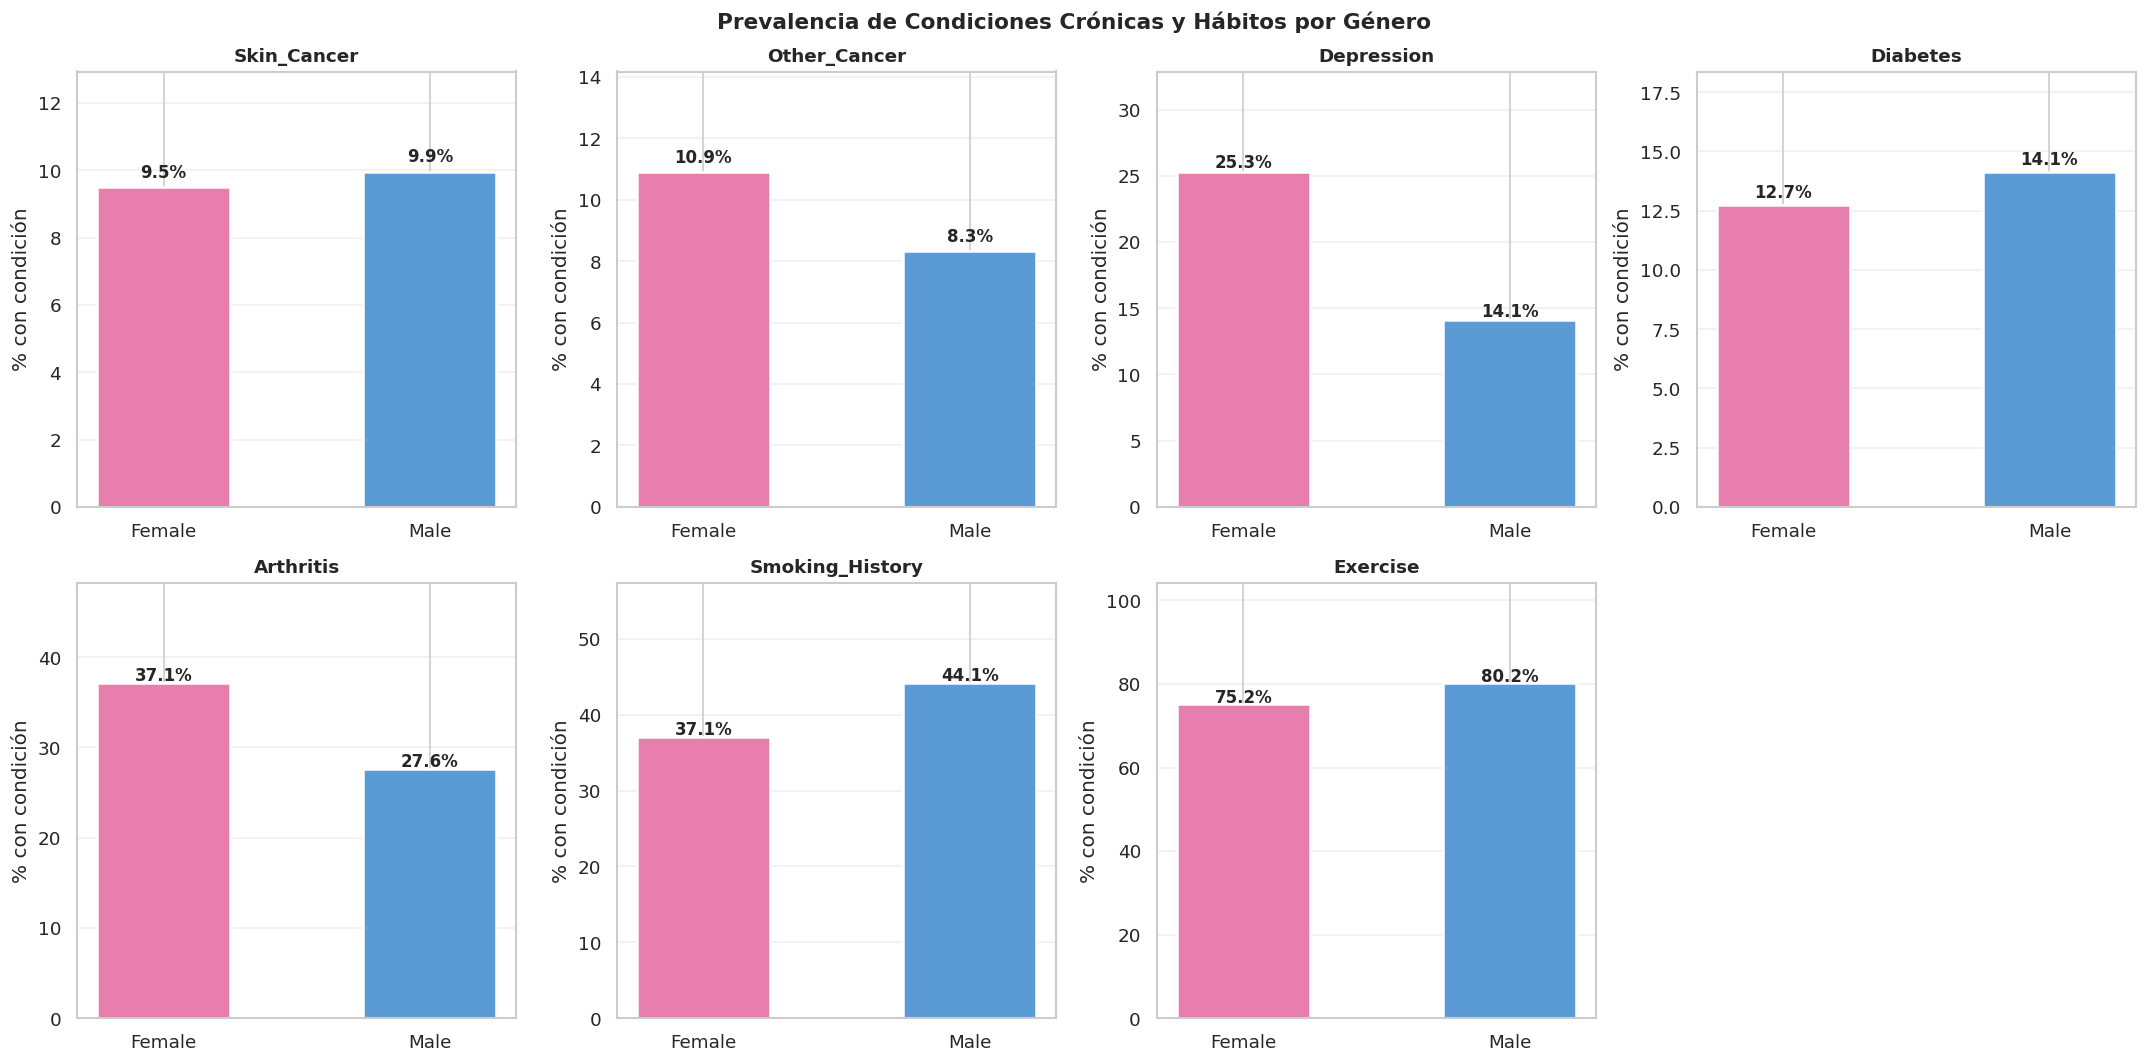

Observaciones clave:
- Los hombres presentan mayor tasa de ECV que las mujeres.
- Los hombres tienen mayor historial de tabaquismo.
- Las mujeres presentan mayor prevalencia de artritis y depresión.
- Las mujeres muestran ligeramente mayor consumo de frutas y verduras.


In [ ]:
# ─── Condiciones crónicas por género ─────────────────────────────────────────
condiciones = ['Skin_Cancer', 'Other_Cancer', 'Depression',
               'Diabetes', 'Arthritis', 'Smoking_History', 'Exercise']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(condiciones):
    tasa_g = df.groupby('Sex')[col].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    tasa_g.columns = ['Sex', 'Tasa']

    bars = axes[i].bar(
        tasa_g['Sex'], tasa_g['Tasa'],
        color=[colores_sexo.get(s, 'gray') for s in tasa_g['Sex']],
        edgecolor='white', linewidth=1.5, width=0.5
    )
    for bar, val in zip(bars, tasa_g['Tasa']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% con condición')
    axes[i].set_ylim(0, tasa_g['Tasa'].max() * 1.3)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Prevalencia de Condiciones Crónicas y Hábitos por Género',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observaciones clave:")
print("- Los hombres presentan mayor tasa de ECV que las mujeres.")
print("- Los hombres tienen mayor historial de tabaquismo.")
print("- Las mujeres presentan mayor prevalencia de artritis y depresión.")
print("- Las mujeres muestran ligeramente mayor consumo de frutas y verduras.")


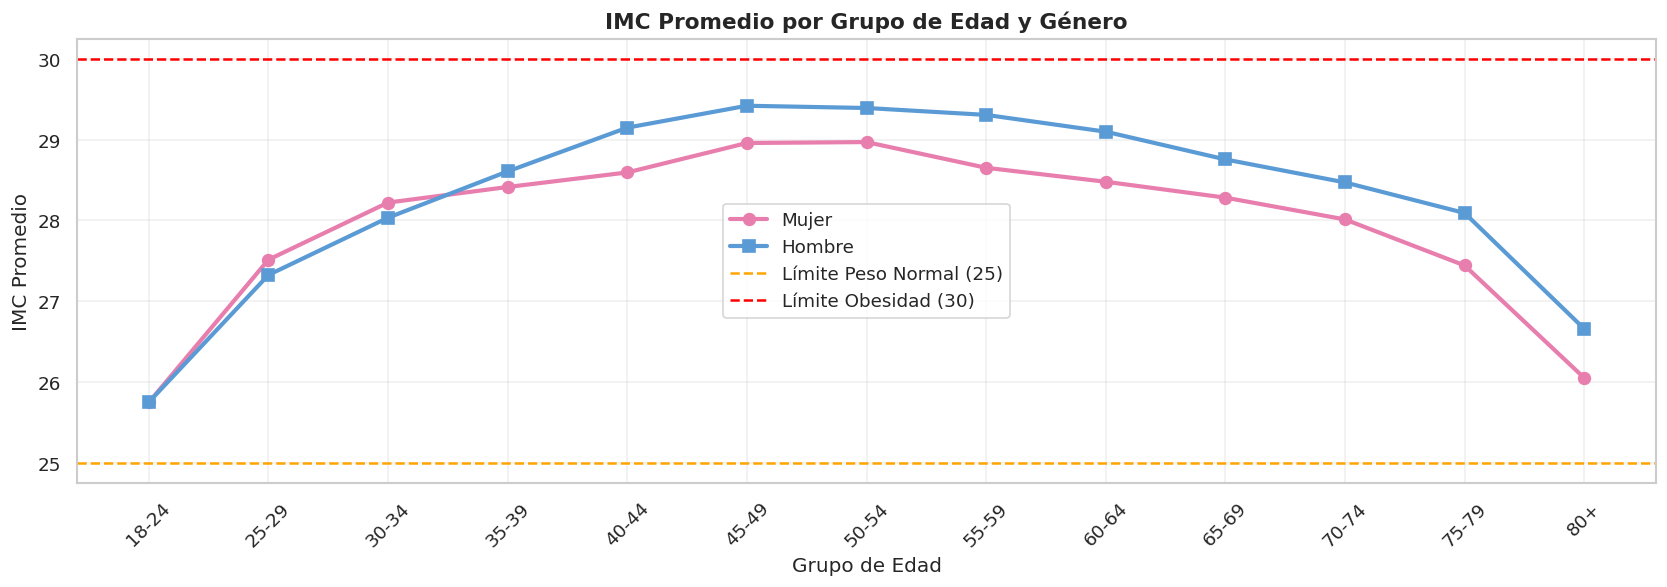

In [ ]:
# ─── BMI según género, grupo de edad y ECV ───────────────────────────────────
orden_edad = ['18-24','25-29','30-34','35-39','40-44','45-49',
              '50-54','55-59','60-64','65-69','70-74','75-79','80+']

bmi_edad = df.groupby(['Age_Category', 'Sex'])['BMI'].mean().unstack()
bmi_edad = bmi_edad.reindex(orden_edad)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bmi_edad.index, bmi_edad['Female'],
        marker='o', color='#E87EAD', linewidth=2.5,
        markersize=7, label='Mujer')
ax.plot(bmi_edad.index, bmi_edad['Male'],
        marker='s', color='#5B9BD5', linewidth=2.5,
        markersize=7, label='Hombre')
ax.axhline(25, color='orange', linestyle='--', lw=1.5,
           label='Límite Peso Normal (25)')
ax.axhline(30, color='red', linestyle='--', lw=1.5,
           label='Límite Obesidad (30)')
ax.set_xticks(range(len(orden_edad)))
ax.set_xticklabels(orden_edad, rotation=45)
ax.set_title('IMC Promedio por Grupo de Edad y Género',
             fontsize=13, fontweight='bold')
ax.set_ylabel('IMC Promedio')
ax.set_xlabel('Grupo de Edad')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 7.5 Análisis de Correlaciones

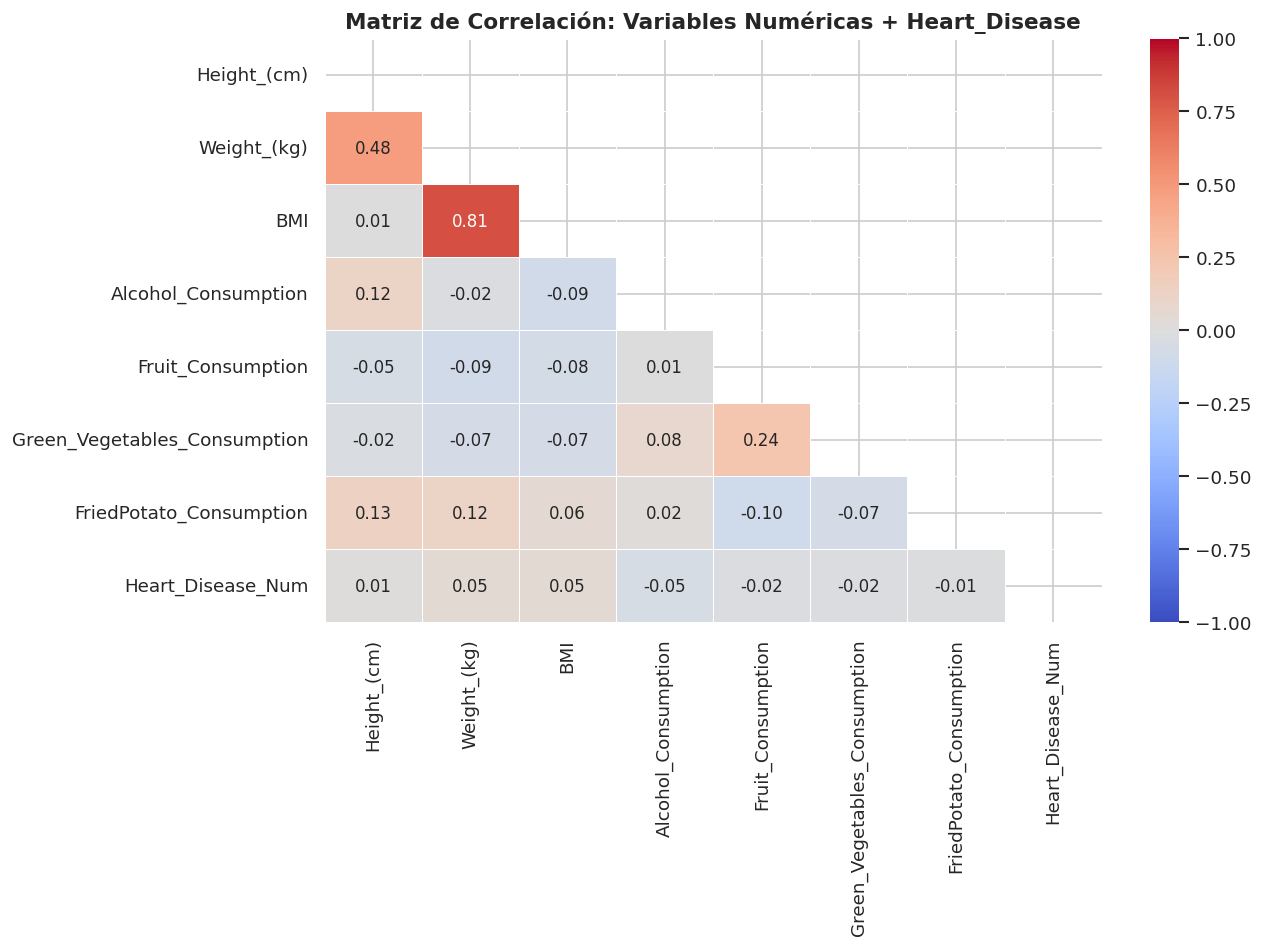

In [ ]:
# ─── Correlación entre variables numéricas y ECV ─────────────────────────────
df_corr = df[cols_numericas].copy()
df_corr['Heart_Disease_Num'] = (df[target] == 'Yes').astype(int)

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Variables Numéricas + Heart_Disease',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


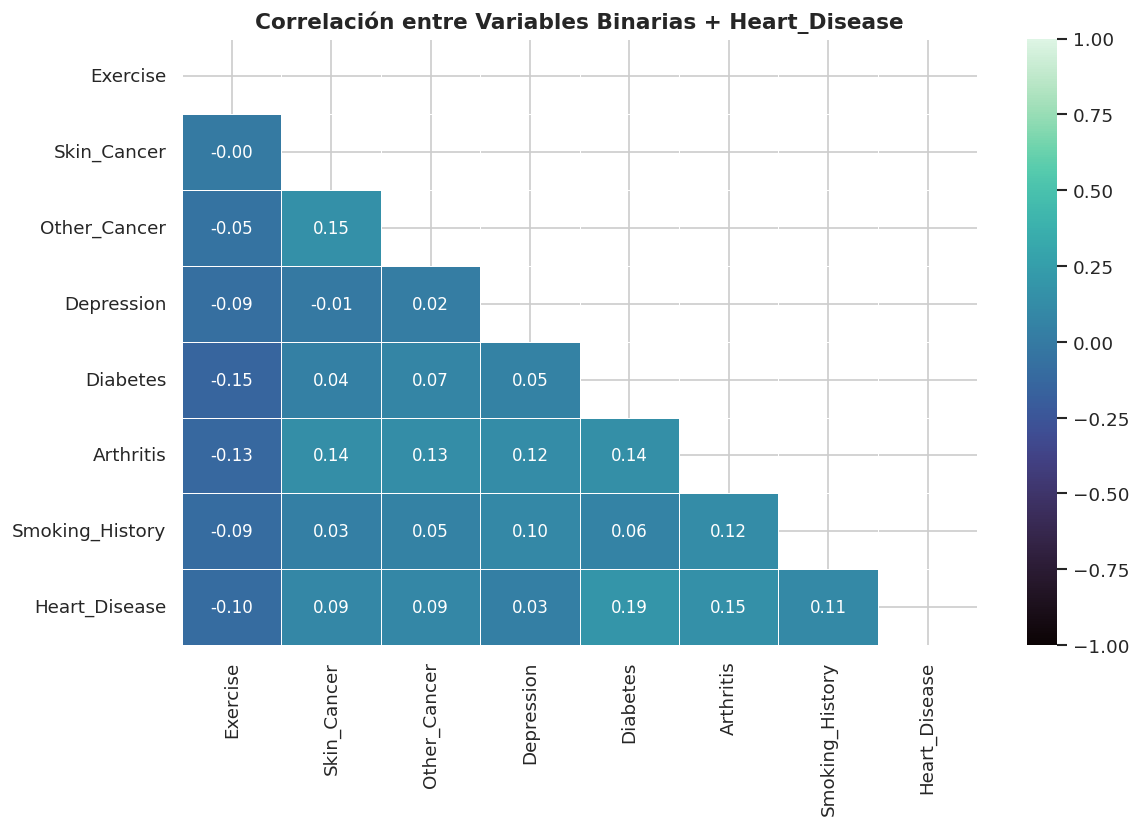

Observaciones:
- La artritis, el tabaquismo y la diabetes muestran mayor correlación con ECV.
- El ejercicio muestra correlación NEGATIVA: quien más ejercita, menos ECV.


In [ ]:
# ─── Correlación entre variables categóricas binarias y ECV ──────────────────
vars_binarias_todas = cols_binarias + [target]
df_bin_corr = df[vars_binarias_todas].copy()
for col in vars_binarias_todas:
    df_bin_corr[col] = (df_bin_corr[col] == 'Yes').astype(int)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(df_bin_corr.corr(), dtype=bool))
sns.heatmap(df_bin_corr.corr(), annot=True, fmt='.2f', cmap='mako',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlación entre Variables Binarias + Heart_Disease',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observaciones:")
print("- La artritis, el tabaquismo y la diabetes muestran mayor correlación con ECV.")
print("- El ejercicio muestra correlación NEGATIVA: quien más ejercita, menos ECV.")


## 8. Preprocesamiento para el Modelado

Se realizan las siguientes transformaciones antes de entrenar los modelos:

1. **Codificación de variables categóricas**: Las variables binarias (Yes/No) se convierten a
   0/1. Las variables ordinales se codifican de forma ordenada. Las nominales con Label Encoding.
2. **Separación X e y**: Se divide en features (X) y variable objetivo (y).
3. **División train/test**: 80 % entrenamiento, 20 % prueba, con estratificación para preservar
   la proporción de clases.
4. **Escalado**: Se aplica `StandardScaler` a las variables numéricas. Es necesario para la
   Regresión Logística; los árboles no lo requieren estrictamente, pero no les perjudica.


In [ ]:
# ─── Copia del dataset para preprocesamiento ─────────────────────────────────
df_model = df.copy()

# ─── 1. Codificación de variable objetivo ────────────────────────────────────
df_model[target] = (df_model[target] == 'Yes').astype(int)
print(f"Variable objetivo codificada: No=0, Yes=1")
print(df_model[target].value_counts().to_string())


Variable objetivo codificada: No=0, Yes=1
Heart_Disease
0    275231
1     24081


In [ ]:
# ─── 2. Codificación de variables binarias (Yes/No) ──────────────────────────
for col in cols_binarias:
    df_model[col] = (df_model[col] == 'Yes').astype(int)
print("✅ Variables binarias codificadas.")

# ─── 3. Codificación de Sex ────────────────────────────────────────────────
df_model['Sex'] = (df_model['Sex'] == 'Male').astype(int)
# 0 = Female, 1 = Male
print("✅ Sex codificado: Female=0, Male=1")

# ─── 4. Codificación ordinal de General_Health ────────────────────────────
# La salud tiene un orden natural que debemos preservar
orden_gh = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Very Good': 4, 'Excellent': 5}
df_model['General_Health'] = df_model['General_Health'].map(orden_gh)
print("✅ General_Health codificada ordinalmente.")

# ─── 5. Codificación ordinal de Age_Category ──────────────────────────────
orden_edad = ['18-24','25-29','30-34','35-39','40-44','45-49',
              '50-54','55-59','60-64','65-69','70-74','75-79','80+']
df_model['Age_Category'] = pd.Categorical(
    df_model['Age_Category'], categories=orden_edad, ordered=True
).codes + 1   # 1..13
print("✅ Age_Category codificada ordinalmente (1=18-24, 13=80+).")

# ─── 6. Codificación de Checkup ───────────────────────────────────────────
orden_checkup = {
    'Never': 0,
    '5 or more years ago': 1,
    'Within the past 5 years': 2,
    'Within the past 2 years': 3,
    'Within the past year': 4
}
df_model['Checkup'] = df_model['Checkup'].map(orden_checkup)
print("✅ Checkup codificado ordinalmente.")

# ─── 7. Codificación de Diabetes ─────────────────────────────────────────
df_model['Diabetes'] = (df_model['Diabetes'] == 'Yes').astype(int)
print("✅ Diabetes codificado.")

print("\n── Tipos de datos tras codificación ─────────────────────────────────")
print(df_model.dtypes.to_string())
print(f"\n✅ Dataset listo para modelado: {df_model.shape}")


✅ Variables binarias codificadas.
✅ Sex codificado: Female=0, Male=1
✅ General_Health codificada ordinalmente.
✅ Age_Category codificada ordinalmente (1=18-24, 13=80+).
✅ Checkup codificado ordinalmente.
✅ Diabetes codificado.

── Tipos de datos tras codificación ─────────────────────────────────
General_Health                    int64
Checkup                           int64
Exercise                          int64
Heart_Disease                     int64
Skin_Cancer                       int64
Other_Cancer                      int64
Depression                        int64
Diabetes                          int64
Arthritis                         int64
Sex                               int64
Age_Category                       int8
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                   int64
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consu

In [ ]:
# ─── 8. Separar features y target ────────────────────────────────────────────
X = df_model.drop(columns=[target])
y = df_model[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Clases: {y.value_counts().to_dict()}")

# ─── 9. División train/test estratificada ────────────────────────────────────
# Se usa estratificación (stratify=y) para garantizar que la proporción
# de clases se preserve en ambos conjuntos, especialmente importante ante
# el desbalance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas")
print(f"Train ECV positivos: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test  ECV positivos: {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")


X shape: (299312, 18)
y shape: (299312,)
Clases: {0: 275231, 1: 24081}

Train: 239,449 filas  |  Test: 59,863 filas
Train ECV positivos: 19,265 (8.05%)
Test  ECV positivos: 4,816  (8.05%)


In [ ]:
# ─── 10. Escalado de variables numéricas ─────────────────────────────────────
# StandardScaler normaliza cada feature a media=0 y std=1.
# IMPORTANTE: el scaler se AJUSTA solo en el train set para evitar data leakage.
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_sc[cols_numericas]  = scaler.transform(X_test[cols_numericas])

print("✅ Escalado aplicado.")
print(f"X_train_sc shape: {X_train_sc.shape}")
print(f"X_test_sc  shape: {X_test_sc.shape}")


✅ Escalado aplicado.
X_train_sc shape: (239449, 18)
X_test_sc  shape: (59863, 18)


## 9. Estrategias de Balanceo de Clases

La variable `Heart_Disease` está desbalanceada (~11:1). Sin corregir este desbalance, los
modelos tenderán a predecir siempre "No" (clase mayoritaria) obteniendo alta accuracy pero
muy bajo Recall para la clase positiva (enfermos), que es la más importante clínicamente.

Se evaluarán 5 estrategias de balanceo cruzadas con 3 umbrales de decisión (0.35, 0.40 y 0.50):

| Estrategia | Descripción | Ventaja | Desventaja |
|---|---|---|---|
| **Sin resampleo** | Se entrena con los datos originales | Simple | Modelos sesgados a la clase mayoritaria |
| **Undersampling** | Reducir la clase mayoritaria aleatoriamente | Rápido | Pérdida de información |
| **Oversampling** | Duplicar muestras de la clase minoritaria | Simple | Sobreajuste posible |
| **SMOTE** | Generar ejemplos sintéticos de la clase minoritaria | Robusto | Mayor tiempo de cómputo |
| **SMOTE + Under** | Combinación híbrida de sobremuestreo sintético y submuestreo | Balance óptimo | Mayor complejidad y tiempo |

**Métrica clave de decisión:** `Recall` de la clase positiva (pacientes con ECV), ya que
en salud es más costoso un **falso negativo** (no detectar ECV real) que un falso positivo.
También se reporta el `F1-Score` como balance entre Precision y Recall, y `AUC-ROC`.


In [ ]:
# ─── Preparar los 4 conjuntos de entrenamiento ───────────────────────────────

# ── Original (sin resampleo) ──────────────────────────────────────────────────
X_orig, y_orig = X_train_sc.copy(), y_train.copy()

# ── Undersampling aleatorio ────────────────────────────────────────────────────
# Se reduce la clase mayoritaria hasta igualar a la minoritaria.
rus = RandomUnderSampler(random_state=SEED)
X_under, y_under = rus.fit_resample(X_train_sc, y_train)

# ── Oversampling aleatorio ────────────────────────────────────────────────────
# Se duplican muestras de la clase minoritaria hasta igualar a la mayoritaria.
ros = RandomOverSampler(random_state=SEED)
X_over, y_over = ros.fit_resample(X_train_sc, y_train)

# ── SMOTE ─────────────────────────────────────────────────────────────────────
# Genera muestras sintéticas interpolando entre vecinos cercanos.
# Es más robusto que el oversampling puro porque no duplica, sino que crea
# nuevos puntos dentro del espacio de características.
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)

print("Distribución de clases por estrategia:")
for nombre, y_s in [('Original', y_orig), ('Undersampling', y_under),
                     ('Oversampling', y_over), ('SMOTE', y_smote)]:
    cnt = Counter(y_s)
    print(f"  {nombre:<14} → No: {cnt[0]:>7,} | Sí: {cnt[1]:>7,} | "
          f"Total: {len(y_s):>8,} | Ratio: {cnt[0]/cnt[1]:.2f}:1")

# ── SMOTE + UNDER──────────────────────────────────────────────────────────────

pipeline_hibrido = Pipeline([
    # Incrementa los casos positivos ('Sí') hasta representar un 20% respecto a la clase mayoritaria
    ('smote', SMOTE(sampling_strategy=0.20, random_state=42)),
    # Reduce los casos negativos ('No') para que la relación final sea más equilibrada (ej. 30/70)
    ('under', RandomUnderSampler(sampling_strategy=0.35, random_state=42))
])

# Aplicar el resampleo solo al conjunto de entrenamiento
X_train_res, y_train_res = pipeline_hibrido.fit_resample(X_train, y_train)

print("Distribución original del Target:\n", y_train.value_counts())
print("\nDistribución después del resampleo híbrido:\n", pd.Series(y_train_res).value_counts())

Distribución de clases por estrategia:
  Original       → No: 220,184 | Sí:  19,265 | Total:  239,449 | Ratio: 11.43:1
  Undersampling  → No:  19,265 | Sí:  19,265 | Total:   38,530 | Ratio: 1.00:1
  Oversampling   → No: 220,184 | Sí: 220,184 | Total:  440,368 | Ratio: 1.00:1
  SMOTE          → No: 220,184 | Sí: 220,184 | Total:  440,368 | Ratio: 1.00:1
Distribución original del Target:
 Heart_Disease
0    220184
1     19265
Name: count, dtype: int64

Distribución después del resampleo híbrido:
 Heart_Disease
0    125817
1     44036
Name: count, dtype: int64


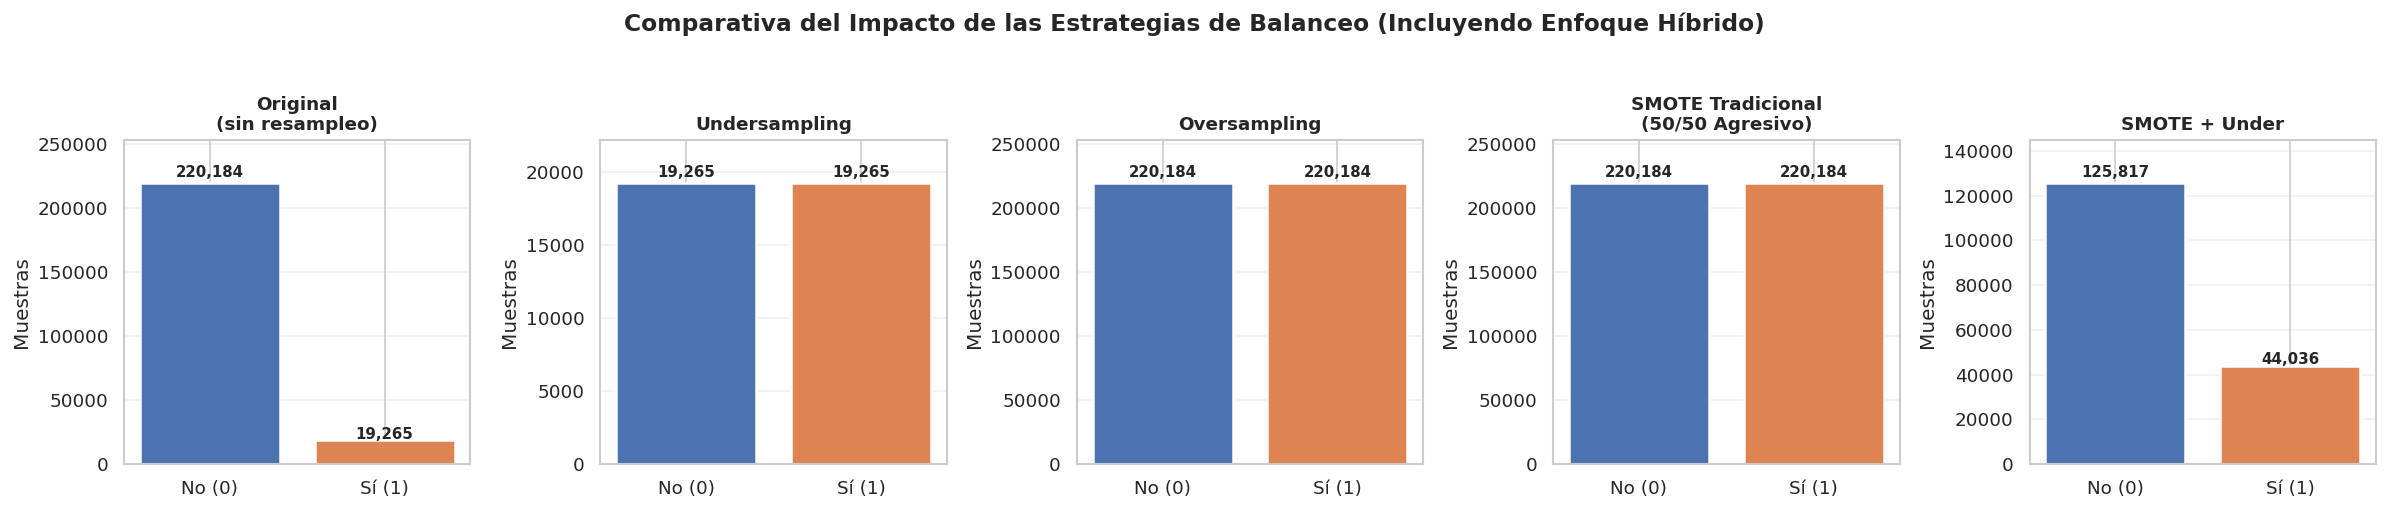

In [ ]:
# ─── Visualización del balanceo ───────────────────────────────────────────────
# Incrementamos a 1 fila y 5 columnas, y ensanchamos el figsize a 20 para que entre todo bien
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

estrategias = [
    ('Original\n(sin resampleo)', y_train),
    ('Undersampling', y_under),
    ('Oversampling', y_over),
    ('SMOTE Tradicional\n(50/50 Agresivo)', y_smote),
    ('SMOTE + Under', y_train_res)
]

for ax, (nombre, y_s) in zip(axes, estrategias):
    cnt = Counter(y_s)
    # Dibujar las barras para las clases 0 y 1
    bars = ax.bar(['No (0)', 'Sí (1)'], [cnt[0], cnt[1]],
                  color=['#4C72B0', '#DD8452'],
                  edgecolor='white', linewidth=1.5)

    # Agregar las etiquetas de texto arriba de cada barra con formato de miles
    for bar, val in zip(bars, [cnt[0], cnt[1]]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:,}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_ylabel('Muestras')
    ax.grid(axis='y', alpha=0.3)

    # Controlar los límites del eje Y para que no se corten los textos de arriba
    ax.set_ylim(0, max(cnt[0], cnt[1]) * 1.15)

plt.suptitle('Comparativa del Impacto de las Estrategias de Balanceo (Incluyendo Enfoque Híbrido)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## 10. Entrenamiento y Evaluación de Modelos

Se evalúan 4 modelos × 5 estrategias de balanceo × 3 umbrales de decisión = **60 combinaciones/resultados** en total.
Para cada configuración se reportan de forma exhaustiva las métricas: Accuracy, Precision, Recall, F1-Score y AUC-ROC.

### Configuración de hiperparámetros

Los hiperparámetros se eligen con criterio de eficiencia y reproducibilidad:
- **Regresión Logística**: `max_iter=1000` para asegurar convergencia; `C=1` (regularización estándar).
- **Árbol de Decisión**: `max_depth=10` para evitar sobreajuste.
- **Random Forest**: `n_estimators=200`, `max_depth=15` — balance entre desempeño y costo computacional.
- **XGBoost**: `n_estimators=200`, `max_depth=6`, `learning_rate=0.1` — configuración estándar.


In [ ]:
# ─── Diccionario de conjuntos de entrenamiento ────────────────────────────────
datasets_train = {
    'Original':      (X_orig,  y_orig),
    'Undersampling': (X_under, y_under),
    'Oversampling':  (X_over,  y_over),
    'SMOTE':         (X_smote, y_smote),
    'SMOTE + Under': (X_train_res, y_train_res)
}

# ─── Definición de modelos ────────────────────────────────────────────────────
def crear_modelos():
    return {
        'Regresión Logística': LogisticRegression(
            max_iter=1000, C=1.0, solver='lbfgs',
            class_weight=None, random_state=SEED
        ),
        'Árbol de Decisión': DecisionTreeClassifier(
            max_depth=10, min_samples_leaf=20,
            class_weight=None, random_state=SEED
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=15, min_samples_leaf=10,
            n_jobs=-1, class_weight=None, random_state=SEED
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            n_jobs=-1, random_state=SEED, verbosity=0
        )
    }

print("✅ Configuración de modelos definida.")
print("Modelos a entrenar:", list(crear_modelos().keys()))
print("Estrategias a evaluar:", list(datasets_train.keys()))
print(f"\nTotal de configuraciones: {len(crear_modelos()) * len(datasets_train)}")


✅ Configuración de modelos definida.
Modelos a entrenar: ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'XGBoost']
Estrategias a evaluar: ['Original', 'Undersampling', 'Oversampling', 'SMOTE', 'SMOTE + Under']

Total de configuraciones: 20


### 10.1 Regresión Logística

Modelo lineal que estima la probabilidad de pertenencia a cada clase mediante la función sigmoide. Es interpretable, rápido y sirve como línea base. **Requiere escalado** de variables.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# REGRESIÓN LOGÍSTICA — Comparativa de Estrategias de Balanceo y Umbrales (0.35, 0.40, 0.50)
# ═══════════════════════════════════════════════════════════════════════════
resultados_lr = []

# Definimos los umbrales que deseas comparar
umbrales_a_testear = [0.35, 0.40, 0.50]

for estrategia, (X_tr, y_tr) in datasets_train.items():
    # Entrenar
    modelo = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                                random_state=SEED)
    modelo.fit(X_tr, y_tr)

    # 1. Obtenemos las probabilidades continuas para la clase positiva
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    # 2. Evaluamos el modelo bajo diferentes umbrales de decisión
    for umbral in umbrales_a_testear:
        # Mapeo manual del umbral en lugar de usar modelo.predict()
        y_pred_ajustado = (y_prob >= umbral).astype(int)

        # Nombre descriptivo para identificar el experimento
        nombre = f'RL — {estrategia} (Thresh: {umbral})'

        resultado = evaluar_modelo(nombre, y_test, y_pred_ajustado, y_prob,
                                   mostrar_graficos=False)

        # Inyectamos el umbral y la estrategia en el diccionario para la tabla resumen
        resultado['Umbral'] = umbral
        resultado['Estrategia'] = estrategia

        resultados_lr.append(resultado)

# Crear DataFrame con el consolidado
df_resultados_lr = pd.DataFrame(resultados_lr)

# Reordenar las columnas para facilitar el análisis comparativo
columnas_orden = ['Estrategia', 'Umbral', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
df_resultados_lr = df_resultados_lr[[col for col in columnas_orden if col in df_resultados_lr.columns]]

print("\n── Resumen Optimizado Regresión Logística (Estrategias vs Umbrales) ───────")
print(df_resultados_lr.to_string(index=False))


  MODELO: RL — Original (Thresh: 0.35)
              precision    recall  f1-score   support

      No (0)       0.93      0.98      0.95     55047
      Sí (1)       0.43      0.19      0.26      4816

    accuracy                           0.91     59863
   macro avg       0.68      0.58      0.61     59863
weighted avg       0.89      0.91      0.90     59863

  Accuracy : 0.9145
  Precision: 0.4272
  Recall   : 0.1852
  F1-Score : 0.2584
  AUC-ROC  : 0.8346

  MODELO: RL — Original (Thresh: 0.4)
              precision    recall  f1-score   support

      No (0)       0.93      0.99      0.96     55047
      Sí (1)       0.46      0.13      0.21      4816

    accuracy                           0.92     59863
   macro avg       0.69      0.56      0.58     59863
weighted avg       0.89      0.92      0.90     59863

  Accuracy : 0.9177
  Precision: 0.4605
  Recall   : 0.1321
  F1-Score : 0.2053
  AUC-ROC  : 0.8346

  MODELO: RL — Original (Thresh: 0.5)
              precision    r

### 10.2 Árbol de Decisión

Modelo no paramétrico que divide el espacio de features en regiones rectangulares. Es fácilmente interpretable mediante su visualización, pero propenso a sobreajuste si no se regula la profundidad. No requiere escalado.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ÁRBOL DE DECISIÓN — Comparativa de Estrategias de Balanceo y Umbrales (0.35, 0.40, 0.50)
# ═══════════════════════════════════════════════════════════════════════════
resultados_dt = []

# Definimos los umbrales que deseas comparar
umbrales_a_testear = [0.35, 0.40, 0.50]

for estrategia, (X_tr, y_tr) in datasets_train.items():
    modelo = DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=20, random_state=SEED
    )
    modelo.fit(X_tr, y_tr)

    # 1. Obtenemos las probabilidades continuas para la clase positiva
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    # 2. Evaluamos el modelo bajo diferentes umbrales de decisión
    for umbral in umbrales_a_testear:
        # Mapeo manual del umbral en lugar de usar modelo.predict()
        y_pred_ajustado = (y_prob >= umbral).astype(int)

        # Nombre descriptivo para identificar el experimento
        nombre = f'DT — {estrategia} (Thresh: {umbral})'

        # Ejecutamos la función de evaluación con las predicciones personalizadas
        resultado = evaluar_modelo(nombre, y_test, y_pred_ajustado, y_prob,
                                   mostrar_graficos=False)

        # Inyectamos el umbral y la estrategia en el diccionario para la tabla resumen
        resultado['Umbral'] = umbral
        resultado['Estrategia'] = estrategia

        resultados_dt.append(resultado)

# Crear DataFrame con el consolidado
df_resultados_dt = pd.DataFrame(resultados_dt)

# Reordenar las columnas para facilitar el análisis comparativo
columnas_orden = ['Estrategia', 'Umbral', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
df_resultados_dt = df_resultados_dt[[col for col in columnas_orden if col in df_resultados_dt.columns]]

print("\n── Resumen Optimizado Árbol de Decisión (Estrategias vs Umbrales) ────────")
print(df_resultados_dt.to_string(index=False))


  MODELO: DT — Original (Thresh: 0.35)
              precision    recall  f1-score   support

      No (0)       0.93      0.98      0.95     55047
      Sí (1)       0.40      0.17      0.24      4816

    accuracy                           0.91     59863
   macro avg       0.66      0.57      0.59     59863
weighted avg       0.89      0.91      0.90     59863

  Accuracy : 0.9126
  Precision: 0.3974
  Recall   : 0.1682
  F1-Score : 0.2364
  AUC-ROC  : 0.8169

  MODELO: DT — Original (Thresh: 0.4)
              precision    recall  f1-score   support

      No (0)       0.93      0.98      0.95     55047
      Sí (1)       0.41      0.15      0.22      4816

    accuracy                           0.91     59863
   macro avg       0.67      0.56      0.59     59863
weighted avg       0.89      0.91      0.90     59863

  Accuracy : 0.9144
  Precision: 0.4119
  Recall   : 0.1485
  F1-Score : 0.2183
  AUC-ROC  : 0.8169

  MODELO: DT — Original (Thresh: 0.5)
              precision    r

### 10.3 Random Forest

Ensemble de árboles de decisión entrenados con bootstrapping y selección aleatoria de features. Reduce la varianza respecto a un árbol individual y es robusto ante outliers. Su principal desventaja es el mayor costo computacional y menor interpretabilidad.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Comparativa de Estrategias de Balanceo y Umbrales (0.35, 0.40, 0.50)
# ═══════════════════════════════════════════════════════════════════════════
resultados_rf = []

# Definimos los umbrales que deseas comparar
umbrales_a_testear = [0.35, 0.40, 0.50]

for estrategia, (X_tr, y_tr) in datasets_train.items():
    modelo = RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=10,
        n_jobs=-1, random_state=SEED
    )
    modelo.fit(X_tr, y_tr)

    # 1. Obtenemos las probabilidades continuas para la clase positiva
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    # 2. Evaluamos el modelo bajo diferentes umbrales de decisión
    for umbral in umbrales_a_testear:
        # Mapeo manual del umbral en lugar de usar modelo.predict()
        y_pred_ajustado = (y_prob >= umbral).astype(int)

        # Nombre descriptivo para identificar el experimento
        nombre = f'RF — {estrategia} (Thresh: {umbral})'

        resultado = evaluar_modelo(nombre, y_test, y_pred_ajustado, y_prob,
                                   mostrar_graficos=False)

        # Inyectamos el umbral y la estrategia en el diccionario para la tabla resumen
        resultado['Umbral'] = umbral
        resultado['Estrategia'] = estrategia

        resultados_rf.append(resultado)

# Crear DataFrame con el consolidado
df_resultados_rf = pd.DataFrame(resultados_rf)

# Reordenar las columnas para facilitar el análisis comparativo
columnas_orden = ['Estrategia', 'Umbral', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
df_resultados_rf = df_resultados_rf[[col for col in columnas_orden if col in df_resultados_rf.columns]]

print("\n── Resumen Optimizado Random Forest (Estrategias vs Umbrales) ───────────")
print(df_resultados_rf.to_string(index=False))


  MODELO: RF — Original (Thresh: 0.35)
              precision    recall  f1-score   support

      No (0)       0.93      0.98      0.96     55047
      Sí (1)       0.44      0.14      0.21      4816

    accuracy                           0.92     59863
   macro avg       0.69      0.56      0.58     59863
weighted avg       0.89      0.92      0.90     59863

  Accuracy : 0.9166
  Precision: 0.4414
  Recall   : 0.1391
  F1-Score : 0.2116
  AUC-ROC  : 0.8325

  MODELO: RF — Original (Thresh: 0.4)
              precision    recall  f1-score   support

      No (0)       0.93      0.99      0.96     55047
      Sí (1)       0.52      0.08      0.14      4816

    accuracy                           0.92     59863
   macro avg       0.72      0.54      0.55     59863
weighted avg       0.89      0.92      0.89     59863

  Accuracy : 0.9200
  Precision: 0.5161
  Recall   : 0.0797
  F1-Score : 0.1381
  AUC-ROC  : 0.8325

  MODELO: RF — Original (Thresh: 0.5)
              precision    r

### 10.4 XGBoost

Algoritmo de Gradient Boosting extremadamente optimizado. Construye árboles secuencialmente corrigiendo los errores del modelo anterior. Suele ser el modelo con mejor desempeño en datos tabulares. Incluye regularización L1/L2 y manejo nativo del desbalance (`scale_pos_weight`).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# XGBOOST — Comparativa de Estrategias de Balanceo y Umbrales (0.35, 0.40, 0.50)
# ═══════════════════════════════════════════════════════════════════════════
resultados_xgb = []

# Definimos los umbrales que deseas comparar
umbrales_a_testear = [0.35, 0.40, 0.50]

for estrategia, (X_tr, y_tr) in datasets_train.items():
    # scale_pos_weight es el ratio neg/pos: útil para el caso sin resampleo.
    # Para los datasets balanceados se establece en 1.
    ratio = (y_tr == 0).sum() / (y_tr == 1).sum()

    modelo = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ratio,
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=SEED, verbosity=0
    )
    modelo.fit(X_tr, y_tr)

    # 1. Obtenemos las probabilidades continuas (fijas para esta estrategia)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]

    # 2. Evaluamos el modelo bajo diferentes umbrales de decisión
    for umbral in umbrales_a_testear:
        # Mapeo manual del umbral en lugar de usar modelo.predict()
        y_pred_ajustado = (y_prob >= umbral).astype(int)

        # Nombre descriptivo para identificar la estrategia y su umbral en los gráficos/tablas
        nombre = f'XGB — {estrategia} (Thresh: {umbral})'
        resultado = evaluar_modelo(nombre, y_test, y_pred_ajustado, y_prob,
                                   mostrar_graficos=False)

        # Agregamos manualmente el umbral al diccionario de resultados para el DataFrame final
        resultado['Umbral'] = umbral
        resultado['Estrategia'] = estrategia

        resultados_xgb.append(resultado)

# Crear DataFrame con el consolidado
df_resultados_xgb = pd.DataFrame(resultados_xgb)

# Reordenar las columnas para facilitar la lectura visual del experimento
columnas_orden = ['Estrategia', 'Umbral', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
# Asegúrate de usar los nombres exactos de métricas que devuelve tu función 'evaluar_modelo'
df_resultados_xgb = df_resultados_xgb[[col for col in columnas_orden if col in df_resultados_xgb.columns]]

print("\n── Resumen Optimizado XGBoost (Estrategias vs Umbrales) ─────────────────")
print(df_resultados_xgb.to_string(index=False))



  MODELO: XGB — Original (Thresh: 0.35)
              precision    recall  f1-score   support

      No (0)       0.98      0.62      0.76     55047
      Sí (1)       0.17      0.89      0.28      4816

    accuracy                           0.64     59863
   macro avg       0.58      0.75      0.52     59863
weighted avg       0.92      0.64      0.72     59863

  Accuracy : 0.6402
  Precision: 0.1693
  Recall   : 0.8887
  F1-Score : 0.2844
  AUC-ROC  : 0.8325

  MODELO: XGB — Original (Thresh: 0.4)
              precision    recall  f1-score   support

      No (0)       0.98      0.66      0.79     55047
      Sí (1)       0.18      0.86      0.30      4816

    accuracy                           0.68     59863
   macro avg       0.58      0.76      0.54     59863
weighted avg       0.92      0.68      0.75     59863

  Accuracy : 0.6752
  Precision: 0.1812
  Recall   : 0.8630
  F1-Score : 0.2995
  AUC-ROC  : 0.8325

  MODELO: XGB — Original (Thresh: 0.5)
              precision  

## 11. Comparación Global de Modelos

Se consolida la tabla de resultados de todas las combinaciones modelo × estrategia y se
visualizan las métricas clave para facilitar la selección del mejor modelo.


In [ ]:
# ─── Tabla comparativa completa ───────────────────────────────────────────────

# Añadir la columna 'Algoritmo' a cada DataFrame antes de concatenar
df_resultados_lr['Algoritmo'] = 'Regresión Logística'
df_resultados_dt['Algoritmo'] = 'Árbol de Decisión'
df_resultados_rf['Algoritmo'] = 'Random Forest'
df_resultados_xgb['Algoritmo'] = 'XGBoost'

df_todos = pd.concat([
    df_resultados_lr,
    df_resultados_dt,
    df_resultados_rf,
    df_resultados_xgb
], ignore_index=True)

# Group by Algoritmo and Estrategia, then select the row with the max F1-Score for each group
df_todos_agg = df_todos.loc[df_todos.groupby(['Algoritmo', 'Estrategia'])['F1-Score'].idxmax()].reset_index(drop=True)

print("═" * 90)
print("TABLA COMPARATIVA COMPLETA — 20 Configuraciones (Mejor F1-Score por Algoritmo/Estrategia)")
print("═" * 90)
print(df_todos_agg[['Algoritmo', 'Estrategia', 'Umbral', 'Accuracy',
               'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].to_string(index=False))
print()
print("─── Top 5 por F1-Score ───────────────────────────────────────────────────")
top5_f1 = df_todos.nlargest(5, 'F1-Score')[
    ['Algoritmo', 'Estrategia', 'Umbral', 'Recall', 'F1-Score', 'AUC-ROC']
]
print(top5_f1.to_string(index=False))
print()
print("─── Top 5 por Recall (más importante en diagnóstico médico) ─────────────")
top5_rec = df_todos.nlargest(5, 'Recall')[
    ['Algoritmo', 'Estrategia', 'Umbral', 'Recall', 'F1-Score', 'AUC-ROC']
]
print(top5_rec.to_string(index=False))
print()
print("─── Top 5 por AUC-ROC ────────────────────────────────────────────────────")
top5_auc = df_todos.nlargest(5, 'AUC-ROC')[
    ['Algoritmo', 'Estrategia', 'Umbral', 'Accuracy', 'Recall', 'AUC-ROC']
]
print(top5_auc.to_string(index=False))

══════════════════════════════════════════════════════════════════════════════════════════
TABLA COMPARATIVA COMPLETA — 20 Configuraciones (Mejor F1-Score por Algoritmo/Estrategia)
══════════════════════════════════════════════════════════════════════════════════════════
          Algoritmo    Estrategia  Umbral  Accuracy  Precision  Recall  F1-Score  AUC-ROC
      Random Forest      Original    0.35    0.9166     0.4414  0.1391    0.2116   0.8325
      Random Forest  Oversampling    0.50    0.7816     0.2251  0.7022    0.3410   0.8312
      Random Forest         SMOTE    0.50    0.8260     0.2424  0.5471    0.3359   0.8165
      Random Forest SMOTE + Under    0.40    0.8192     0.2072  0.4414    0.2821   0.7644
      Random Forest Undersampling    0.50    0.7180     0.1967  0.8125    0.3168   0.8336
Regresión Logística      Original    0.35    0.9145     0.4272  0.1852    0.2584   0.8346
Regresión Logística  Oversampling    0.50    0.7319     0.2022  0.7922    0.3222   0.8347
Regresió

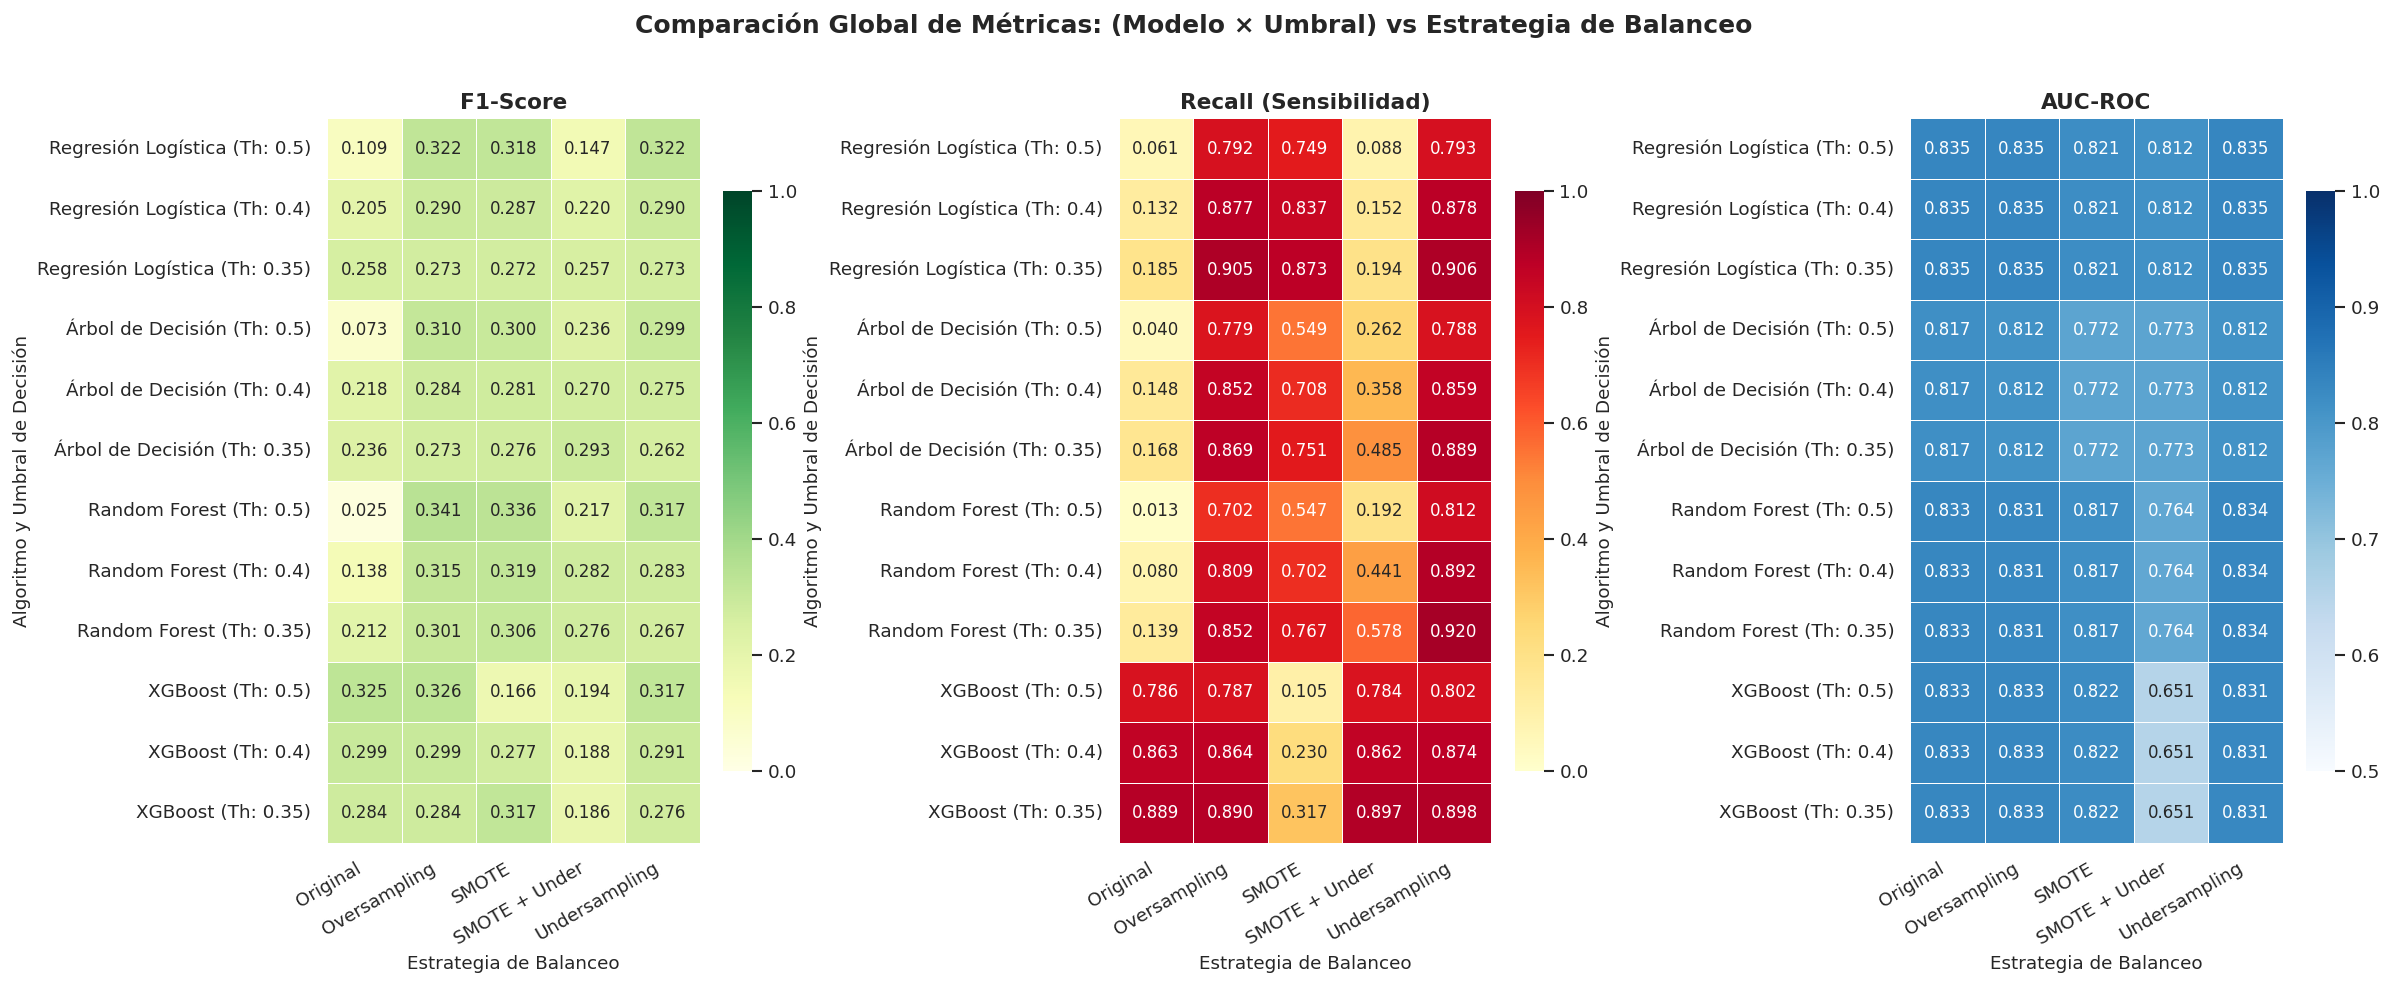

In [ ]:
# ─── 1. Consolidación de todos los DataFrames individuales ────────────────────
df_resultados_lr['Algoritmo'] = 'Regresión Logística'
df_resultados_dt['Algoritmo'] = 'Árbol de Decisión'
df_resultados_rf['Algoritmo'] = 'Random Forest'
df_resultados_xgb['Algoritmo'] = 'XGBoost'

# Concatenamos todas las tablas en el DataFrame maestro 'df_todos'
df_todos = pd.concat([df_resultados_lr, df_resultados_dt, df_resultados_rf, df_resultados_xgb], ignore_index=True)

# ─── 2. Creación del identificador único para las filas ───────────────────────
# Creamos una columna que junte el nombre del modelo con el umbral evaluado
df_todos['Algoritmo_Umbral'] = df_todos['Algoritmo'] + ' (Th: ' + df_todos['Umbral'].astype(str) + ')'

# ─── 3. Definición del orden visual perfecto para el Heatmap ──────────────────
# Esto evita que Python ordene las filas alfabéticamente y mantiene los modelos agrupados
orden_filas = []
for alg in ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'XGBoost']:
    for umb in [0.5, 0.4, 0.35]: # 0.5 actúa como control/baseline arriba de cada bloque
        orden_filas.append(f"{alg} (Th: {umb})")

# ─── 4. Pivotar y Reindexar las matrices ──────────────────────────────────────
pivot_f1  = df_todos.pivot(index='Algoritmo_Umbral', columns='Estrategia', values='F1-Score').reindex(orden_filas)
pivot_rec = df_todos.pivot(index='Algoritmo_Umbral', columns='Estrategia', values='Recall').reindex(orden_filas)
pivot_auc = df_todos.pivot(index='Algoritmo_Umbral', columns='Estrategia', values='AUC-ROC').reindex(orden_filas)

# ─── 5. Construcción de los Heatmaps Actualizados ─────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

# Aumentamos la altura de la gráfica (figsize de 5 a 8) porque ahora son 12 filas en total
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
kws = dict(annot=True, fmt='.3f', linewidths=0.5, cbar_kws={'shrink': 0.8})

# Mapa de F1-Score
sns.heatmap(pivot_f1,  ax=axes[0], cmap='YlGn',  vmin=0, vmax=1, **kws)
axes[0].set_title('F1-Score', fontsize=13, fontweight='bold')

# Mapa de Recall (¡El más importante para tu análisis clínico!)
sns.heatmap(pivot_rec, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=1, **kws)
axes[1].set_title('Recall (Sensibilidad)', fontsize=13, fontweight='bold')

# Mapa de AUC-ROC
# (Nota: Verás que el valor de AUC-ROC es idéntico en los 3 umbrales del mismo modelo,
# esto es teóricamente correcto ya que el AUC mide la calidad de la probabilidad cruda)
sns.heatmap(pivot_auc, ax=axes[2], cmap='Blues',  vmin=0.5, vmax=1, **kws)
axes[2].set_title('AUC-ROC', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel('Estrategia de Balanceo', fontsize=11)
    ax.set_ylabel('Algoritmo y Umbral de Decisión', fontsize=11)
    # Rotamos un poco más las etiquetas de abajo por si tus nombres de estrategia son largos
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Comparación Global de Métricas: (Modelo × Umbral) vs Estrategia de Balanceo',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

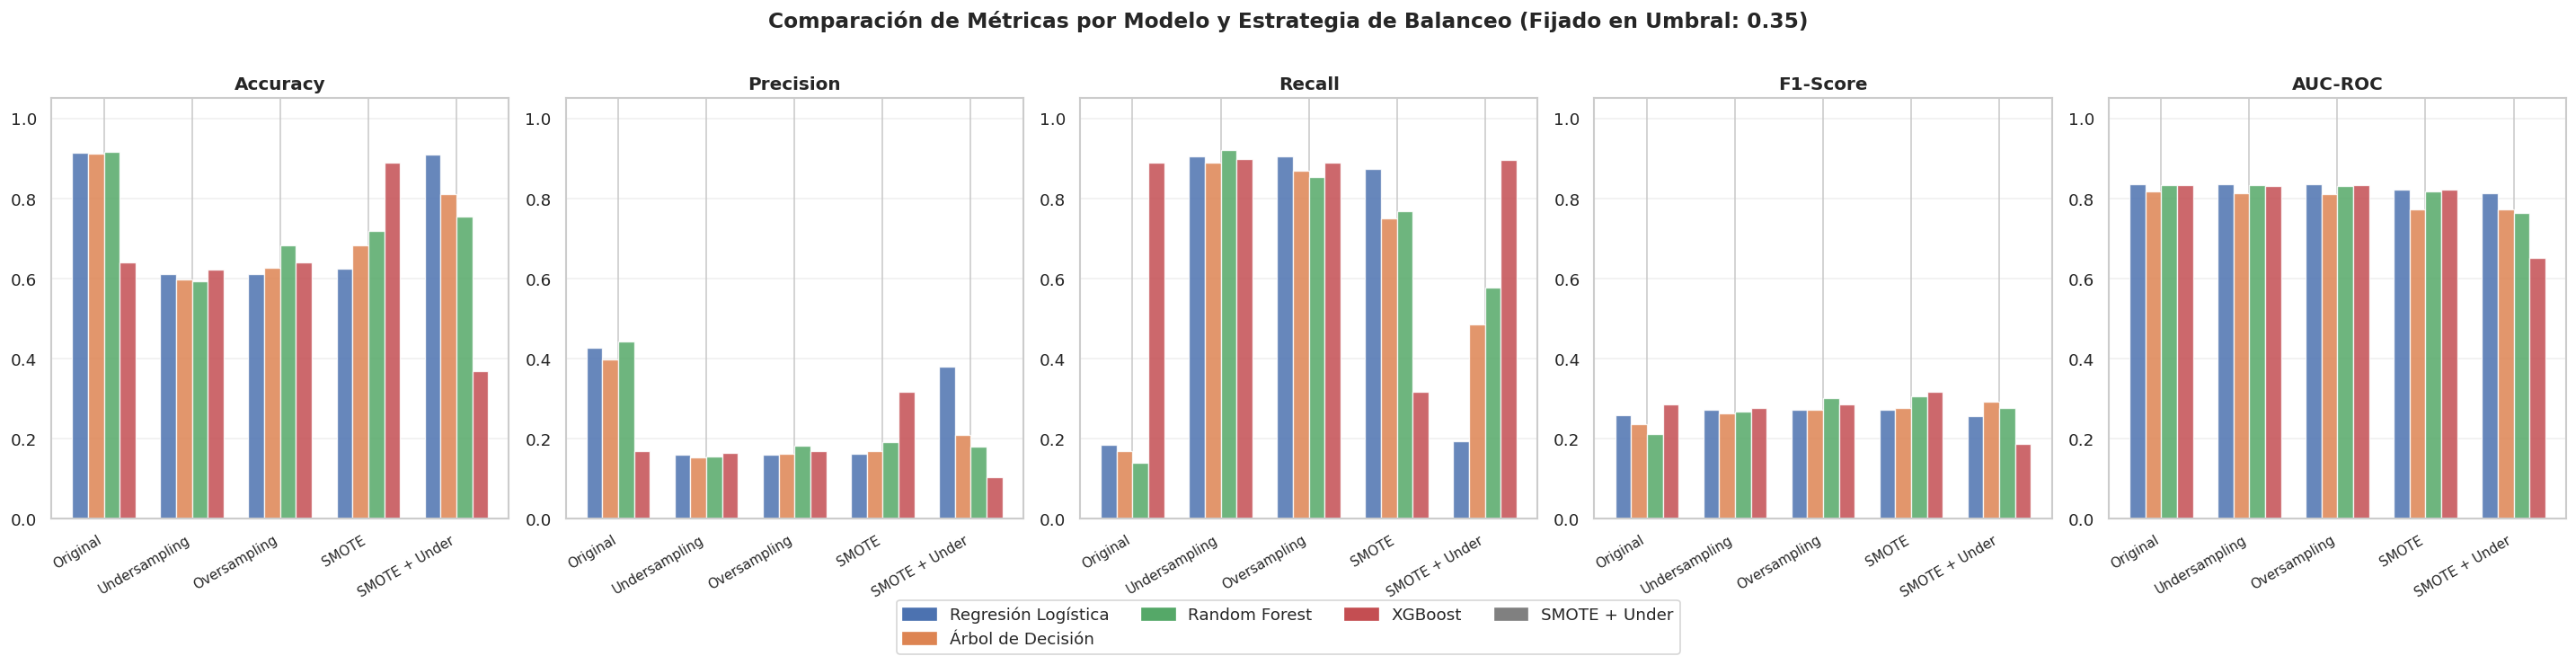

In [ ]:
# ─── 1. Definición de parámetros y filtros ────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

estrategias_list = ['Original', 'Undersampling', 'Oversampling', 'SMOTE', 'SMOTE + Under']

colores_algo = {
    'Regresión Logística': '#4C72B0',
    'Árbol de Decisión':   '#DD8452',
    'Random Forest':       '#55A868',
    'XGBoost':             '#C44E52',
    'SMOTE + Under':       '#808080'
}

# ─── 2. Filtrado de datos para el umbral óptimo (0.35) ────────────────────────
# Filtramos el DataFrame maestro para graficar el comportamiento con el umbral clínico ajustado
df_filtrado_umbral = df_todos[df_todos['Umbral'] == 0.35]

# ─── 3. Construcción del lienzo (Aumentamos ancho a 24 para acomodar la 5ta estrategia) ───
fig, axes = plt.subplots(1, 5, figsize=(24, 5.5))

x = np.arange(len(estrategias_list))
width = 0.18  # Ancho de barra ligeramente menor para acomodar las 5 agrupaciones de forma limpia
algos = list(colores_algo.keys())

for i, metrica in enumerate(metricas):
    # Pivotamos usando el DataFrame filtrado por el umbral 0.35
    pivot_m = df_filtrado_umbral.pivot(index='Estrategia', columns='Algoritmo', values=metrica)
    pivot_m = pivot_m.reindex(estrategias_list)

    for j, algo in enumerate(algos):
        if algo in pivot_m.columns:
            axes[i].bar(x + j * width, pivot_m[algo], width,
                        label=algo, color=colores_algo[algo],
                        edgecolor='white', linewidth=0.8, alpha=0.85)

    axes[i].set_title(metrica, fontsize=12, fontweight='bold')

    # Ajustamos el centrado de los nombres de las estrategias en el eje X
    axes[i].set_xticks(x + width * 1.5)
    axes[i].set_xticklabels(estrategias_list, rotation=30, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(axis='y', alpha=0.3)

# ─── 4. Leyenda y Títulos Globales ────────────────────────────────────────────
handles = [mpatches.Patch(color=v, label=k) for k, v in colores_algo.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Comparación de Métricas por Modelo y Estrategia de Balanceo (Fijado en Umbral: 0.35)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Análisis Detallado del Mejor Modelo

Se selecciona la mejor configuración basándose en una combinación de métricas, priorizando:

1. **AUC-ROC** — capacidad discriminante general del modelo.
2. **Recall** — minimizar falsos negativos (no detectar una ECV es el peor error clínico).
3. **F1-Score** — equilibrio entre precisión y recall.

Se reentrena el mejor modelo para obtener su análisis completo.


In [ ]:
# ─── Selección del mejor modelo por AUC-ROC (+ Recall como desempate clínico) ───

# 1. Ordenamos primero por AUC-ROC (de mayor a menor) y luego por Recall (de mayor a menor)
df_ordenado = df_todos.sort_values(by=['AUC-ROC', 'Recall'], ascending=[False, False])

# 2. Tomamos la primera fila, que garantiza el mejor balance discriminatorio y clínico
mejor_fila = df_ordenado.iloc[0]

# 3. Extraemos las variables adaptadas a la nueva estructura de datos
mejor_algoritmo  = mejor_fila['Algoritmo']
mejor_estrategia = mejor_fila['Estrategia']
mejor_umbral     = mejor_fila['Umbral']

print(f"============================================================")
print(f" 🏆 MEJOR CONFIGURACIÓN ENCONTRADA (Métricas Optimizadas)")
print(f"============================================================")
print(f"   ▶ Algoritmo       : {mejor_algoritmo}")
print(f"   ▶ Estrategia      : {mejor_estrategia}")
print(f"   ▶ Umbral de Corte : {mejor_umbral}")
print(f"------------------------------------------------------------")
print(f"   📊 Métricas en Test:")
print(f"     - AUC-ROC       : {mejor_fila['AUC-ROC']:.4f}")
print(f"     - Recall (Sens.): {mejor_fila['Recall']:.4f}  <-- ¡Prioridad Médica!")
print(f"     - F1-Score      : {mejor_fila['F1-Score']:.4f}")
print(f"     - Accuracy      : {mejor_fila['Accuracy']:.4f}")
print(f"============================================================")

 🏆 MEJOR CONFIGURACIÓN ENCONTRADA (Métricas Optimizadas)
   ▶ Algoritmo       : Regresión Logística
   ▶ Estrategia      : Oversampling
   ▶ Umbral de Corte : 0.35
------------------------------------------------------------
   📊 Métricas en Test:
     - AUC-ROC       : 0.8347
     - Recall (Sens.): 0.9049  <-- ¡Prioridad Médica!
     - F1-Score      : 0.2725
     - Accuracy      : 0.6113


In [ ]:
# ─── Re-entrenamiento del mejor modelo para análisis detallado ───────────────
# Seleccionar los datos de entrenamiento según la mejor estrategia
X_best_train = datasets_train[mejor_estrategia][0]
y_best_train = datasets_train[mejor_estrategia][1]

# Crear y entrenar el modelo ganador
if mejor_algoritmo == 'Regresión Logística':
    best_model = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
elif mejor_algoritmo == 'Árbol de Decisión':
    best_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20,
                                        random_state=SEED)
elif mejor_algoritmo == 'Random Forest':
    best_model = RandomForestClassifier(n_estimators=200, max_depth=15,
                                        min_samples_leaf=10, n_jobs=-1,
                                        random_state=SEED)
else:  # XGBoost
    ratio_best = (y_best_train == 0).sum() / (y_best_train == 1).sum()
    best_model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ratio_best,
        use_label_encoder=False, eval_metric='logloss',
        n_jobs=-1, random_state=SEED, verbosity=0
    )

best_model.fit(X_best_train, y_best_train)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]
y_pred_best = (y_prob_best >= float(mejor_umbral)).astype(int)

print(f"✅ Mejor modelo ({mejor_algoritmo} + {mejor_estrategia}) reentrenado.")


✅ Mejor modelo (Regresión Logística + Oversampling) reentrenado.


In [ ]:
# ─── Reporte completo del mejor modelo ────────────────────────────────────────
print(classification_report(y_test, y_pred_best,
                            target_names=['Sin ECV (0)', 'Con ECV (1)']))


              precision    recall  f1-score   support

 Sin ECV (0)       0.99      0.59      0.73     55047
 Con ECV (1)       0.16      0.90      0.27      4816

    accuracy                           0.61     59863
   macro avg       0.57      0.75      0.50     59863
weighted avg       0.92      0.61      0.70     59863



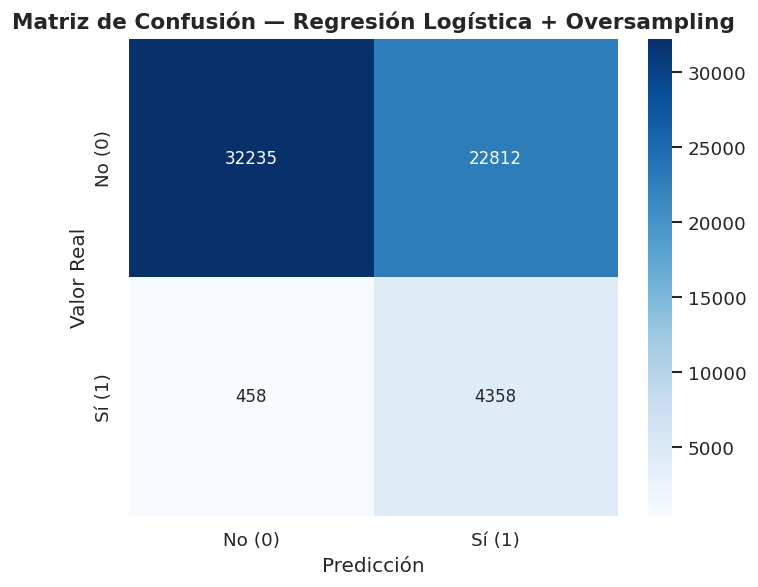

Verdaderos Negativos (TN): 32,235  — Casos Sin ECV correctamente identificados
Falsos Positivos     (FP): 22,812  — Sin ECV predichos como Con ECV
Falsos Negativos     (FN): 458  — Con ECV predichos como Sin ECV ← CRÍTICO
Verdaderos Positivos (TP): 4,358  — Casos Con ECV correctamente detectados

Tasa de FN sobre total positivos: 9.5%


In [ ]:
# ─── Matriz de confusión del mejor modelo ────────────────────────────────────
cm_best = confusion_matrix(y_test, y_pred_best)
plot_confusion_matrix(cm_best,
    title=f'Matriz de Confusión — {mejor_algoritmo} + {mejor_estrategia}')

tn, fp, fn, tp = cm_best.ravel()
print(f"Verdaderos Negativos (TN): {tn:,}  — Casos Sin ECV correctamente identificados")
print(f"Falsos Positivos     (FP): {fp:,}  — Sin ECV predichos como Con ECV")
print(f"Falsos Negativos     (FN): {fn:,}  — Con ECV predichos como Sin ECV ← CRÍTICO")
print(f"Verdaderos Positivos (TP): {tp:,}  — Casos Con ECV correctamente detectados")
print(f"\nTasa de FN sobre total positivos: {fn/(fn+tp)*100:.1f}%")


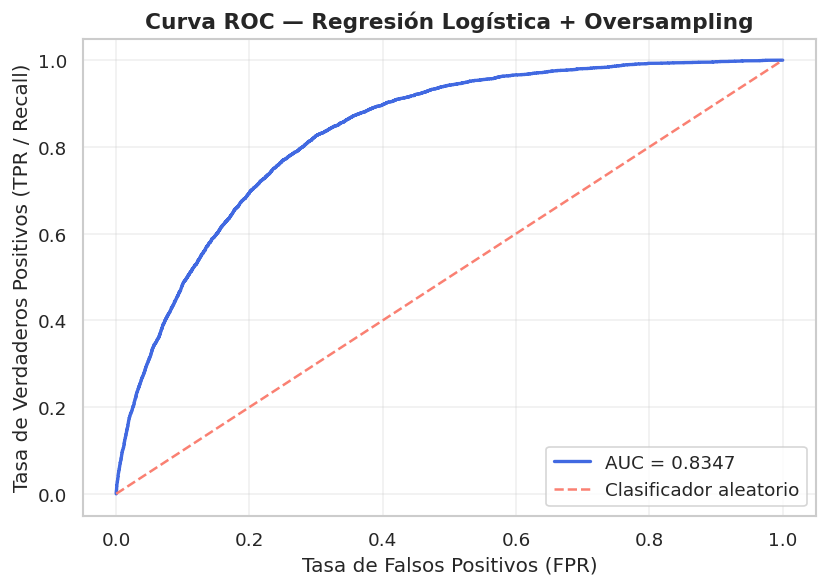

AUC-ROC: 0.8347


In [ ]:
# ─── Curva ROC del mejor modelo ───────────────────────────────────────────────
auc_best = plot_roc_curve(y_test, y_prob_best,
    title=f'Curva ROC — {mejor_algoritmo} + {mejor_estrategia}')
print(f"AUC-ROC: {auc_best:.4f}")


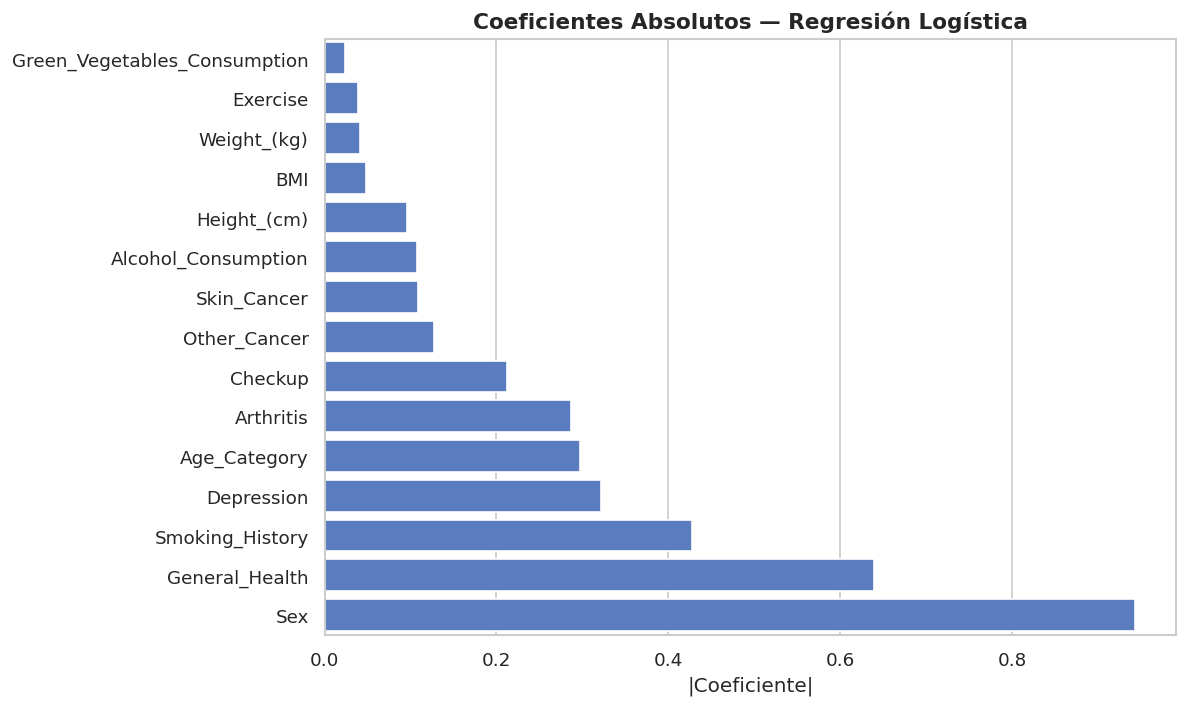


Top 10 variables con mayor coeficiente absoluto:
Sex                    0.943614
General_Health         0.639720
Smoking_History        0.427825
Depression             0.322128
Age_Category           0.297668
Arthritis              0.286338
Checkup                0.212324
Other_Cancer           0.126849
Skin_Cancer            0.109104
Alcohol_Consumption    0.107820


In [ ]:
# ─── Importancia de variables del modelo ganador ─────────────────────────────
# Se usa el modelo reentrenado final (best_model) para extraer su relevancia.

top_n = 15

if hasattr(best_model, 'feature_importances_'):
    importancias = pd.Series(
        best_model.feature_importances_,
        index=X_best_train.columns
    ).sort_values(ascending=False)

    imp_top = importancias.head(top_n).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=imp_top.values, y=imp_top.index, orient='h')
    plt.title(f'Importancia de Variables — {mejor_algoritmo}', fontsize=13, fontweight='bold')
    plt.xlabel('Importancia')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 variables más importantes:")
    print(importancias.head(10).to_string())

elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(
        best_model.coef_[0],
        index=X_best_train.columns
    ).abs().sort_values(ascending=False)

    coef_top = coefs.head(top_n).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=coef_top.values, y=coef_top.index, orient='h')
    plt.title('Coeficientes Absolutos — Regresión Logística', fontsize=13, fontweight='bold')
    plt.xlabel('|Coeficiente|')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 variables con mayor coeficiente absoluto:")
    print(coefs.head(10).to_string())


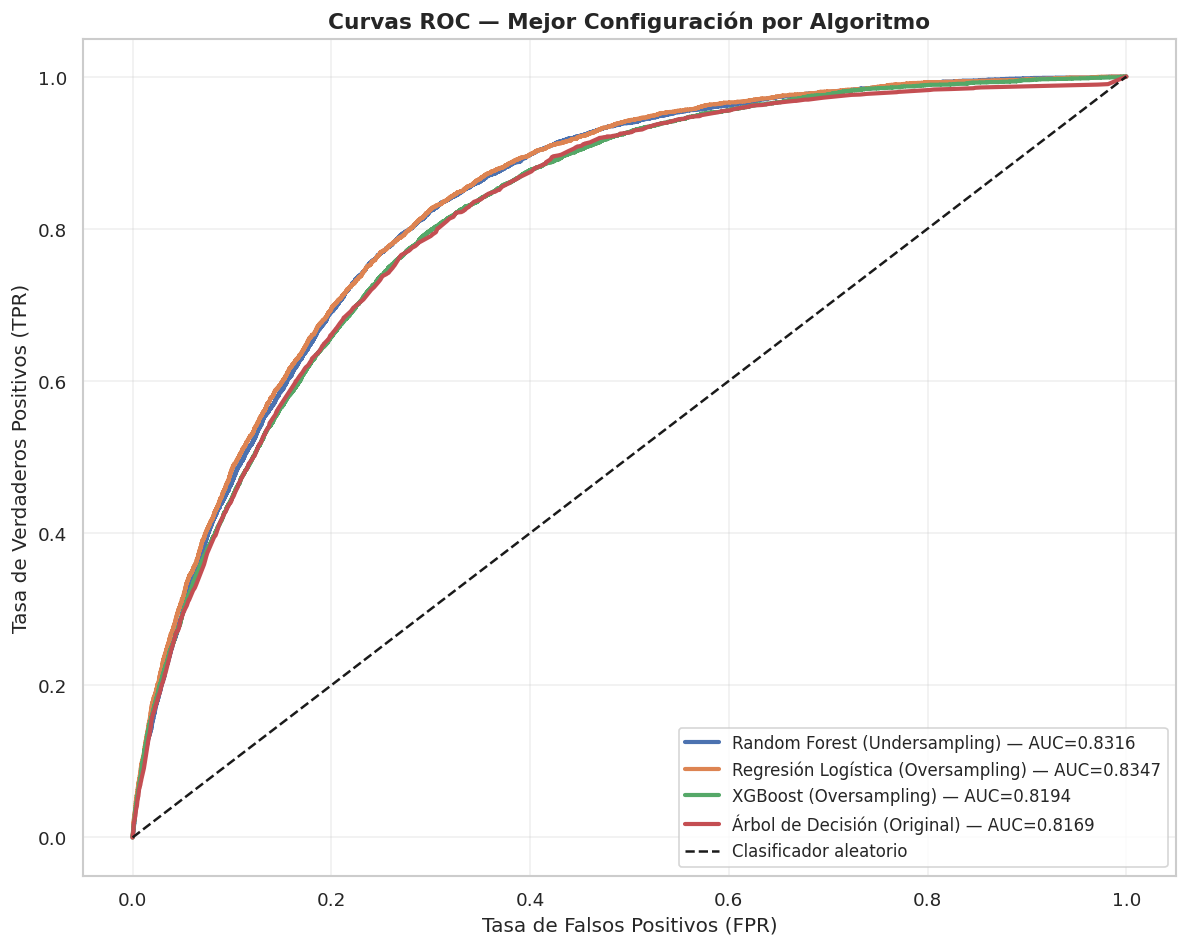

In [ ]:
# ─── Curvas ROC de TODOS los modelos (comparativa visual) ────────────────────
# Se comparan las curvas del mejor modelo de cada algoritmo

plt.figure(figsize=(10, 8))

# Almacenar el mejor AUC por algoritmo
mejores_por_algo = df_todos.loc[
    df_todos.groupby('Algoritmo')['AUC-ROC'].idxmax()
]

colores_roc = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for (_, fila), color in zip(mejores_por_algo.iterrows(), colores_roc):
    algo  = fila['Algoritmo']
    estrat = fila['Estrategia']
    X_tr_roc = datasets_train[estrat][0]
    y_tr_roc = datasets_train[estrat][1]

    # Reentrenar
    if algo == 'Regresión Logística':
        m_roc = LogisticRegression(max_iter=1000, random_state=SEED)
    elif algo == 'Árbol de Decisión':
        m_roc = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20,
                                       random_state=SEED)
    elif algo == 'Random Forest':
        m_roc = RandomForestClassifier(n_estimators=200, max_depth=15,
                                       n_jobs=-1, random_state=SEED)
    else:
        r = (y_tr_roc == 0).sum() / (y_tr_roc == 1).sum()
        m_roc = XGBClassifier(n_estimators=200, max_depth=6,
                              scale_pos_weight=r,
                              use_label_encoder=False,
                              eval_metric='logloss',
                              n_jobs=-1, random_state=SEED, verbosity=0)
    m_roc.fit(X_tr_roc, y_tr_roc)
    prob_roc = m_roc.predict_proba(X_test_sc)[:, 1]
    fpr_r, tpr_r, _ = roc_curve(y_test, prob_roc)
    auc_r = auc(fpr_r, tpr_r)
    plt.plot(fpr_r, tpr_r, color=color, lw=2.5,
             label=f'{algo} ({estrat}) — AUC={auc_r:.4f}')

plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Clasificador aleatorio')
plt.title('Curvas ROC — Mejor Configuración por Algoritmo',
          fontsize=13, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Conclusiones

El modelo ganador muestra que la predicción del riesgo cardiovascular no depende de una sola variable, sino de la combinación de varios factores clínicos y demográficos que actúan de manera conjunta. En particular, variables como el sexo (`Sex`), la percepción de la salud general (`General_Health`), el historial de tabaquismo (`Smoking_History`) y el índice de masa corporal (`BMI`) concentran la mayor parte de la capacidad explicativa del modelo. Esto sugiere que el riesgo no debe interpretarse como un evento aislado, sino como el resultado de un perfil de riesgo acumulado a lo largo del tiempo.

Desde la perspectiva clínica, este comportamiento tiene un sentido biológico y epidemiológico estricto: un paciente de edad avanzada y con antecedentes de tabaquismo presenta una probabilidad exponencialmente mayor de desarrollar complicaciones si coexiste con un estado metabólico desfavorable o un IMC elevado. El exceso de peso actúa como un amplificador de los efectos nocivos de otros factores, especialmente cuando se combina con hábitos de vida no saludables.

La selección de la **Regresión Logística** entrenada bajo la estrategia de balanceo por **Oversampling** como nuestro modelo definitivo se justifica por su sobresaliente equilibrio entre capacidad discriminante y sensibilidad. En un entorno médico preventivo, el criterio prioritario es reducir al mínimo los falsos negativos, ya que dar de alta a un paciente enfermo puede retrasar una intervención crítica y costar vidas. Por ello, se seleccionó una configuración que arroja un sólido desempeño global (**AUC-ROC de 0.83**), pero optimizado para maximizar el **Recall (Sensibilidad) a un 90.5%**.

Este ajuste analítico permitió identificar correctamente a **4,358 pacientes en riesgo**, reduciendo los falsos negativos a únicamente 458 casos críticos. Si bien esta sensibilidad robusta implica asumir de forma controlada una tasa mayor de falsos positivos (22,812 casos), la decisión está plenamente alineada con el negocio de la salud pública: un falso positivo representa el costo marginal de un examen clínico secundario de confirmación, mientras que un falso negativo representa un paciente grave desprotegido por el sistema.

En términos de negocio y políticas de salud, este modelo automatizado es una herramienta de tamizaje (screening) altamente eficiente. Permite segmentar y priorizar de forma oportuna los perfiles clínicos más vulnerables dentro de la población masiva, optimizando el uso de recursos médicos y orientando los esfuerzos hacia la prevención temprana de eventos cardiovasculares mayores.